# Exploration de la Base de Données

## Objectif

Ce notebook a pour objectif d'explorer en profondeur le dataset Ames Housing pour comprendre sa structure, identifier les valeurs manquantes, analyser les corrélations, traiter les outliers, transformer la variable cible, et effectuer des tests ANOVA sur les variables qualitatives.

**Principales étapes** :
- Analyse descriptive complète des données
- Détection et traitement des valeurs manquantes
- Identification et traitement des valeurs aberrantes (outliers)
- Transformation logarithmique de la variable cible (Prix de vente → Prix de vente_log)
- Analyse de corrélation pour les variables quantitatives
- Tests ANOVA pour identifier les variables qualitatives significatives
- Sauvegarde des données traitées

## Prérequis

**Aucun prérequis** - Ce notebook est le point de départ du pipeline.

Ce notebook utilise les données brutes (`data/raw/train.csv` et `data/raw/test.csv`) et génère les fichiers suivants :
- `data/processed/train_outliers_treated.csv` - Données d'entraînement après traitement des outliers
- `data/processed/test_outliers_treated.csv` - Données de test après traitement des outliers
- `data/processed/train_final.csv` - Données finales avec variable cible transformée (Prix de vente_log)

**À exécuter avant** : Aucun (notebook de départ)


In [1]:
# Import des bibliothèques nécessaires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path

# Configuration
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Bibliothèques importées avec succès")


Bibliothèques importées avec succès


In [2]:
# Chargement des données brutes
import pandas as pd

# Chargement des données brutes depuis data/raw
print("=" * 60)
print("CHARGEMENT DES DONNÉES BRUTES")
print("=" * 60)
train_df = pd.read_csv('../data/raw/train.csv', keep_default_na=False, na_filter=False)
test_df = pd.read_csv('../data/raw/test.csv', keep_default_na=False, na_filter=False)

print(f"\nDonnées brutes chargées:")
print(f"   - Train: {train_df.shape[0]} lignes, {train_df.shape[1]} colonnes")
print(f"   - Test: {test_df.shape[0]} lignes, {test_df.shape[1]} colonnes")

CHARGEMENT DES DONNÉES BRUTES

Données brutes chargées:
   - Train: 1460 lignes, 81 colonnes
   - Test: 1459 lignes, 80 colonnes


## 1. Chargement et Aperçu Initial


In [3]:
# Aperçu simple des données brutes (avant mapping)
print("=" * 60)
print("APERÇU DES DONNÉES BRUTES")
print("=" * 60)

# Dimensions
print(f"\nDimensions:")
print(f"   Train: {train_df.shape[0]:,} lignes × {train_df.shape[1]} colonnes")
print(f"   Test:  {test_df.shape[0]:,} lignes × {test_df.shape[1]} colonnes")

# Différence de colonnes
train_only = set(train_df.columns) - set(test_df.columns)
test_only = set(test_df.columns) - set(train_df.columns)
print(f"\nDifférences:")
if train_only:
    print(f"   Colonnes uniquement dans train: {train_only}")
if test_only:
    print(f"   Colonnes uniquement dans test: {test_only}")

# Types de données
print(f"\nTypes de données (Train):")
print(train_df.dtypes.value_counts())

# Aperçu des premières lignes
print(f"\nAperçu des premières lignes:")
train_df.head()


APERÇU DES DONNÉES BRUTES

Dimensions:
   Train: 1,460 lignes × 81 colonnes
   Test:  1,459 lignes × 80 colonnes

Différences:
   Colonnes uniquement dans train: {'SalePrice'}

Types de données (Train):
object    46
int64     35
Name: count, dtype: int64

Aperçu des premières lignes:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65,8450,Pave,NA,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NA,Attchd,2003,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NA,NA,NA,0,2,2008,WD,Normal,208500
1,2,20,RL,80,9600,Pave,NA,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,None,0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NA,NA,NA,0,5,2007,WD,Normal,181500
2,3,60,RL,68,11250,Pave,NA,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NA,NA,NA,0,9,2008,WD,Normal,223500
3,4,70,RL,60,9550,Pave,NA,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,None,0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NA,NA,NA,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84,14260,Pave,NA,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NA,NA,NA,0,12,2008,WD,Normal,250000


In [4]:
def traduire_variables(data):
    """
    Fonction pour mapper les valeurs catégorielles et traduire les noms de colonnes
    en français avant tout traitement.
    
    Cette fonction doit être appliquée immédiatement après le chargement des données brutes.
    
    Parameters:
    -----------
    data : pd.DataFrame
        DataFrame contenant les données brutes
        
    Returns:
    --------
    pd.DataFrame
        DataFrame avec les valeurs catégorielles mappées et les colonnes renommées en français
    """
    # Créer une copie pour éviter de modifier l'original
    data = data.copy()
    
    #################### Labellisation des variables catégorielles
    # Dictionnaires pour les variables catégorielles
    # IMPORTANT: Utiliser les noms de colonnes ANGLAIS car les données brutes sont en anglais
    mapp = {
        # Dictionnaires spécifiques - utiliser les noms de colonnes ANGLAIS
        "MSSubClass": {
            20: "1 ÉTAGE 1946 ET PLUS RÉCENT - TOUS STYLES",
            30: "1 ÉTAGE 1945 ET PLUS ANCIEN",
            40: "1 ÉTAGE AVEC GRENIER AMÉNAGÉ - TOUS ÂGES",
            45: "1 ÉTAGE ET DEMI - NON AMÉNAGÉ - TOUS ÂGES",
            50: "1 ÉTAGE ET DEMI - AMÉNAGÉ - TOUS ÂGES",
            60: "2 ÉTAGES 1946 ET PLUS RÉCENT",
            70: "2 ÉTAGES 1945 ET PLUS ANCIEN",
            75: "2 ÉTAGES ET DEMI - TOUS ÂGES",
            80: "NIVEAUX MULTIPLES OU PARTIELS",
            85: "FOYER DIVISÉ",
            90: "DUPLEX - TOUS STYLES ET ÂGES",
            120: "1 ÉTAGE PUD (Lotissement planifié) - 1946 ET PLUS RÉCENT",
            150: "1 ÉTAGE ET DEMI PUD - TOUS ÂGES",
            160: "2 ÉTAGES PUD - 1946 ET PLUS RÉCENT",
            180: "PUD MULTI-NIVEAUX - INCLUT NIVEAUX DIVISÉS",
            190: "CONVERSION 2 FAMILLES - TOUS STYLES ET ÂGES"
        },

        "MSZoning": {
            'A': "Agriculture",
            'C (all)': "Commercial",
            'FV': "Résidentiel flottant",
            'I': "Industriel",
            'RH': "Résidentiel haute densité",
            'RL': "Résidentiel basse densité",
            'RP': "Résidentiel basse densité (parc)",
            'RM': "Résidentiel densité moyenne"
        },

        "Street": {
            'Grvl': "Gravier",
            'Pave': "Pavé"
        },

        "Alley": {
            'Grvl': "Gravier",
            'Pave': "Pavé",
            'N': "Pas d'accès à une allée",
            'None': "Pas d'accès à une allée"
        },

        "LotShape": {
            'Reg': "Régulier",
            'IR1': "Légèrement irrégulier",
            'IR2': "Modérément irrégulier",
            'IR3': "Irrégulier"
        },

        "LandContour": {
            'Lvl': "Plat/Niveau",
            'Bnk': "Bordure - Montée rapide",
            'HLS': "En pente - Forte inclinaison",
            'Low': "Dépression"
        },

        "Utilities": {
            'AllPub': "Tous les services publics (Électricité, Gaz, Eau, Égout)",
            'NoSewr': "Électricité, Gaz, Eau (Fosse septique)",
            'NoSeWa': "Électricité et Gaz uniquement",
            'ELO': "Électricité uniquement"
        },

        "LotConfig": {
            'Inside': "Lot intérieur",
            'Corner': "Lot d'angle",
            'CulDSac': "Cul-de-sac",
            'FR2': "Double façade",
            'FR3': "Triple façade"
        },

        "LandSlope": {
            'Gtl': "Pente douce",
            'Mod': "Pente modérée",
            'Sev': "Pente sévère"
        },

        "Neighborhood": {
            'Blmngtn': "Bloomington Heights",
            'Blueste': "Bluestem",
            'BrDale': "Briardale",
            'BrkSide': "Brookside",
            'ClearCr': "Clear Creek",
            'CollgCr': "College Creek",
            'Crawfor': "Crawford",
            'Edwards': "Edwards",
            'Gilbert': "Gilbert",
            'IDOTRR': "Iowa DOT et chemin de fer",
            'MeadowV': "Meadow Village",
            'Mitchel': "Mitchell",
            'NAmes': "North Ames",
            'NoRidge': "Northridge",
            'NPkVill': "Northpark Villa",
            'NridgHt': "Northridge Heights",
            'NWAmes': "Northwest Ames",
            'OldTown': "Vieille Ville",
            'SWISU': "Sud et Ouest de l'Université d'État de l'Iowa",
            'Sawyer': "Sawyer",
            'SawyerW': "Sawyer Ouest",
            'Somerst': "Somerset",
            'StoneBr': "Stone Brook",
            'Timber': "Timberland",
            'Veenker': "Veenker"
        },

        "Condition1": {
            'Artery': "Proche d'une artère principale",
            'Feedr': "Proche d'une route secondaire",
            'Norm': "Normale",
            'RRNn': "À moins de 200 pieds d'une voie ferrée nord-sud",
            'RRAn': "Adjacente à une voie ferrée nord-sud",
            'PosN': "Proche d'un espace vert ou parc",
            'PosA': "Adjacente à un espace vert ou parc",
            'RRNe': "À moins de 200 pieds d'une voie ferrée est-ouest",
            'RRAe': "Adjacente à une voie ferrée est-ouest"
        },

        "Condition2": {
            'Artery': "Proche d'une artère principale",
            'Feedr': "Proche d'une route secondaire",
            'Norm': "Normale",
            'RRNn': "À moins de 200 pieds d'une voie ferrée nord-sud",
            'RRAn': "Adjacente à une voie ferrée nord-sud",
            'PosN': "Proche d'un espace vert ou parc",
            'PosA': "Adjacente à un espace vert ou parc",
            'RRNe': "À moins de 200 pieds d'une voie ferrée est-ouest",
            'RRAe': "Adjacente à une voie ferrée est-ouest"
        },

        "BldgType": {
            '1Fam': "Maison individuelle",
            '2fmCon': "Conversion deux familles",
            'Duplex': "Duplex",
            'TwnhsE': "Maison de ville (bout)",
            'Twnhs': "Maison de ville (intérieur)"
        },

        "HouseStyle": {
            '1Story': "Un étage",
            '1.5Fin': "Un étage et demi, aménagé",
            '1.5Unf': "Un étage et demi, non aménagé",
            '2Story': "Deux étages",
            '2.5Fin': "Deux étages et demi, aménagé",
            '2.5Unf': "Deux étages et demi, non aménagé",
            'SFoyer': "Foyer divisé",
            'SLvl': "Niveaux divisés"
        },

        "FireplaceQu": {
            'Ex': "Excellent - Cheminée en maçonnerie exceptionnelle",
            'Gd': "Bon - Cheminée en maçonnerie au rez-de-chaussée",
            'TA': "Moyen - Préfabriquée ou en maçonnerie au sous-sol",
            'Fa': "Médiocre - Préfabriquée au sous-sol",
            'Po': "Mauvais - Poêle de type Ben Franklin",
            'No': "Pas de cheminée",
            'None': "Pas de cheminée"
        },

        "Fence": {
            'GdPrv': "Bonne intimité",
            'MnPrv': "Intimité minimale",
            'GdWo': "Bonne qualité en bois",
            'MnWw': "Qualité minimale en bois/fil",
            'No': "Pas de clôture",
            'None': "Pas de clôture"
        },

        "PoolQC": {
            'Ex': "Excellent",
            'Gd': "Bon",
            'TA': "Moyen",
            'Fa': "Médiocre",
            'Po': "Mauvais",
            'No': "Non applicable",
            'None': "Non applicable"
        },

        "ExterQual": {
            'Ex': "Excellent",
            'Gd': "Bon",
            'TA': "Moyen",
            'Fa': "Médiocre",
            'Po': "Mauvais",
            'None': "Non applicable"
        },

        "ExterCond": {
            'Ex': "Excellent",
            'Gd': "Bon",
            'TA': "Moyen",
            'Fa': "Médiocre",
            'Po': "Mauvais",
            'None': "Non applicable"
        },

        "BsmtQual": {
            'Ex': "Excellent",
            'Gd': "Bon",
            'TA': "Moyen",
            'Fa': "Médiocre",
            'Po': "Mauvais",
            'No': "Non applicable",
            'None': "Non applicable"
        },

        "BsmtCond": {
            'Ex': "Excellent",
            'Gd': "Bon",
            'TA': "Moyen",
            'Fa': "Médiocre",
            'Po': "Mauvais",
            'No': "Non applicable",
            'None': "Non applicable"
        },

        "HeatingQC": {
            'Ex': "Excellent",
            'Gd': "Bon",
            'TA': "Moyen",
            'Fa': "Médiocre",
            'Po': "Mauvais",
            'No': "Non applicable"
        },

        "KitchenQual": {
            'Ex': "Excellent",
            'Gd': "Bon",
            'TA': "Moyen",
            'Fa': "Médiocre",
            'Po': "Mauvais",
            'No': "Non applicable"
        },

        "GarageQual": {
            'Ex': "Excellent",
            'Gd': "Bon",
            'TA': "Moyen",
            'Fa': "Médiocre",
            'Po': "Mauvais",
            'No': "Non applicable",
            'None': "Non applicable"
        },

        "GarageCond": {
            'Ex': "Excellent",
            'Gd': "Bon",
            'TA': "Moyen",
            'Fa': "Médiocre",
            'Po': "Mauvais",
            'No': "Non applicable",
            'None': "Non applicable"
        },

        "OverallQual": {
            10: "Très excellent",
            9: "Excellent",
            8: "Très bon",
            7: "Bon",
            6: "Au-dessus de la moyenne",
            5: "Moyenne",
            4: "En dessous de la moyenne",
            3: "Médiocre",
            2: "Mauvais",
            1: "Très mauvais"
        },

        "OverallCond": {
            10: "Très excellent",
            9: "Excellent",
            8: "Très bon",
            7: "Bon",
            6: "Au-dessus de la moyenne",
            5: "Moyenne",
            4: "En dessous de la moyenne",
            3: "Médiocre",
            2: "Mauvais",
            1: "Très mauvais"
        },
        
        "RoofStyle": {
            'Gable': "Pignon",
            'Hip': "Pente",
            'Mansard': "Mansardé",
            'Flat': "Plat",
            'Shed': "Abri",
            'Gambrel': 'Gabriel (grange)'
        },

        "RoofMatl": {
            'ClyTile': 'Tuile ou argile',
            'CompShg': 'Bardeau composite standard',
            'Membran': 'Membrane',
            'Metal': 'Métal',
            'Roll': 'Rouleau',
            'Tar&Grv': 'Gravier et bitume',
            'WdShake': 'Bardeau de bois',
            'WdShngl': 'Bardeau en bois'
        },

        "Exterior1st": {
            'AsbShng': 'Bardeaux en amiante',
            'AsphShn': 'Bardeaux en asphalte',
            'BrkComm': 'Brique commune',
            'BrkFace': 'Brique apparente',
            'CBlock': 'Bloc de béton',
            'CemntBd': 'Panneau de ciment',
            'HdBoard': 'Panneau dur',
            'ImStucc': 'Stuc imitation',
            'MetalSd': 'Revêtement métallique',
            'Other': 'Autre',
            'Plywood': 'Contreplaqué',
            'PreCast': 'Préfabriqué',
            'Stone': 'Pierre',
            'Stucco': 'Stuc',
            'VinylSd': 'Revêtement en vinyle',
            'Wd Sdng': 'Revêtement en bois',
            'WdShing': 'Bardeaux en bois'
        },
        
        "Exterior2nd": {
            'AsbShng': 'Bardeaux en amiante',
            'AsphShn': 'Bardeaux en asphalte',
            'Brk Cmn': 'Brique commune',
            'BrkFace': 'Brique apparente',
            'CBlock': 'Bloc de béton',
            'CmentBd': 'Panneau de ciment',
            'HdBoard': 'Panneau dur',
            'ImStucc': 'Stuc imitation',
            'MetalSd': 'Revêtement métallique',
            'Other': 'Autre',
            'Plywood': 'Contreplaqué',
            'PreCast': 'Préfabriqué',
            'Stone': 'Pierre',
            'Stucco': 'Stuc',
            'VinylSd': 'Revêtement en vinyle',
            'Wd Sdng': 'Revêtement en bois',
            'WdShing': 'Bardeaux en bois'
        },

        "MasVnrType": {
            'BrkFace': "Briques en façade",
            'Stone': "Pierre",
            'No': "Aucune",
            'BrkCmn': "Briques communes",
            'None': "Aucune"
        },

        "Heating": {
            'GasA': 'Chauffage à gaz',
            'Grav': 'Gravité',
            'Wall': 'Chauffage mural',
            'GasW': 'Chauffage à gaz (chaudière)',
            'Floor': 'Chauffage par le sol',
            'OthW': 'Chauffage à eau chaude ou vapeur (autre que gaz)'
        },

        "Electrical": {
            'SBrkr': 'Disjoncteurs',
            'FuseA': 'Fusibles anciens',
            'FuseF': 'Fusibles',
            'FuseP': 'Fusibles et câblage de mauvaise qualité',
            'Mix': 'Mixte',
            'CircuitBreakers': 'Disjoncteurs modernes',
        },

        "BsmtExposure": {
            'No': "Aucune exposition",
            'Gd': "Bonne exposition",
            'Mn': "Exposition moyenne",
            'Av': "Exposition au niveau moyen",
            'None': "Pas de sous-sol"
        },

        "BsmtFinType1": {
            'GLQ': "Fini - Excellent",
            'ALQ': "Fini - Moyenne",
            'BLQ': "Partiellement fini",
            'Unf': "Non fini",
            'Rec': "Fini - Salle de jeux",
            'LwQ': "Fini - Qualité inférieure",
            'None': "Pas de sous-sol"
        },

        "BsmtFinType2": {
            'GLQ': "Fini - Excellent",
            'ALQ': "Fini - Moyenne",
            'BLQ': "Partiellement fini",
            'Unf': "Non fini",
            'Rec': "Fini - Salle de jeux",
            'LwQ': "Fini - Qualité inférieure",
            'None': "Pas de sous-sol"
        },

        "MiscFeature": {
            'Elev': "Ascenseur",
            'Gar2': "Deuxième garage",
            'Othr': "Autre",
            'Shed': "Abri",
            'TenC': "Court de tennis",
            'None': "Aucune"
        },

        "GarageType": {
            '2Types': "Plus d'un type de garage",
            'Attchd': 'Attaché à la maison',
            'Basment': 'Garage au sous-sol',
            'BuiltIn': 'Garage intégré (fait partie de la maison, souvent avec une pièce au-dessus)',
            'CarPort': 'Abris voiture',
            'Detchd': 'Détaché de la maison',
            'No': "Pas de garage",
            'None': "Pas de garage"
        },
        
        "GarageFinish": {
            'Fin': "Aménagé",
            'RFn': "Partiellement aménagé",
            'Unf': "Non aménagé",
            'No': "Pas de garage",
            'None': "Pas de garage"
        },
        
        "SaleType": {
            'WD': "Acte de garantie - Conventionnel",
            'CWD': "Acte de garantie - Espèces",
            'VWD': "Acte de garantie - Prêt VA",
            'New': "Maison neuve construite et vendue",
            'COD': "Acte de l'officier judiciaire/Etat",
            'Con': "Contrat - 15% acompte, conditions normales",
            'ConLw': "Contrat - Acompte faible et faible taux d'intérêt",
            'ConLI': "Contrat - Faible taux d'intérêt",
            'ConLD': "Contrat - Acompte faible",
            'Oth': 'Autre'
        },

        "SaleCondition": {
            'Normal': 'Vente normale',
            'Abnorml': 'Vente anormale',
            'AdjLand': 'Achat terrain adjoint',
            'Alloca': 'Allocation (propriétés liées)',
            'Family': 'Vente entre membres de la famille',
            'Partial': 'Maison incomplète'
        },

        "CentralAir": {
            'Y': "Oui",
            'N': "Non"
        },

        "PavedDrive": {
            'Y': "Pavé",
            'P': "Pavement partiel",
            'N': "Gravier/Terre"
        },

        "MoSold": {
            1: "Janvier",
            2: "Février",
            3: "Mars",
            4: "Avril",
            5: "Mai",
            6: "Juin",
            7: "Juillet",
            8: "Août",
            9: "Septembre",
            10: "Octobre",
            11: "Novembre",
            12: "Décembre"
        }
    }

    # Application du mapping des valeurs catégorielles
    colonnes_mappees = []
    colonnes_non_trouvees = []
    for el in data.columns:
        if el in mapp:  # Vérifier si la colonne est dans le dictionnaire
            # Utiliser fillna pour gérer les valeurs non mappées (comme "None")
            data[el] = data[el].map(mapp[el]).fillna(data[el])
            colonnes_mappees.append(el)
        else:
            colonnes_non_trouvees.append(el)
    
    print(f"Colonnes avec mapping appliqué: {len(colonnes_mappees)}")
    if colonnes_non_trouvees:
        print(f"Colonnes sans mapping de valeurs: {len(colonnes_non_trouvees)}")

    ####### Fonction de normalisation des noms de colonnes ########################
    def normaliser_nom_colonne(nom):
        """
        Normalise un nom de colonne pour qu'il soit standardisé :
        - Enlève les accents
        - Remplace les espaces par des underscores
        - Enlève les caractères spéciaux (parenthèses, etc.)
        - Convertit en minuscules avec underscores (snake_case)
        """
        import unicodedata
        import re
        
        # Enlever les accents
        nom = unicodedata.normalize('NFD', nom)
        nom = ''.join(c for c in nom if unicodedata.category(c) != 'Mn')
        
        # Remplacer les espaces et caractères spéciaux par des underscores
        nom = re.sub(r'[^\w\s-]', '', nom)  # Enlever caractères spéciaux sauf - et _
        nom = re.sub(r'[\s()]+', '_', nom)  # Remplacer espaces et parenthèses par _
        nom = re.sub(r'_+', '_', nom)  # Remplacer multiples _ par un seul
        nom = nom.strip('_')  # Enlever _ au début et à la fin
        
        # Convertir en minuscules
        nom = nom.lower()
        
        return nom

    ####### Renommage des colonnes avec normalisation ########################
    labels = {
        'Id': 'identifiant',
        'MSSubClass': 'type_de_logement',
        'MSZoning': 'zonage_classification',
        'LotFrontage': 'facade_en_pieds',
        'LotArea': 'superficie_du_lot_pieds',
        'Street': 'type_de_route',
        'Alley': 'acces_a_une_allee',
        'LotShape': 'forme_du_lot',
        'LandContour': 'topographie_du_terrain',
        'Utilities': 'services_publics_disponibles',
        'LotConfig': 'configuration_du_lot',
        'LandSlope': 'inclinaison_du_terrain',
        'Neighborhood': 'quartier',
        'Condition1': 'proximite_1ere_condition',
        'Condition2': 'proximite_2e_condition',
        'BldgType': 'type_de_batiment',
        'HouseStyle': 'style_de_maison',
        'OverallQual': 'qualite_globale',
        'OverallCond': 'etat_general',
        'YearBuilt': 'annee_de_construction',
        'YearRemodAdd': 'annee_de_renovation',
        'RoofStyle': 'style_de_toit',
        'RoofMatl': 'materiau_du_toit',
        'Exterior1st': 'revetement_exterieur_1',
        'Exterior2nd': 'revetement_exterieur_2',
        'MasVnrType': 'type_de_parement_en_maconnerie',
        'MasVnrArea': 'surface_de_parement_pieds',
        'ExterQual': 'qualite_exterieure',
        'ExterCond': 'etat_exterieur',
        'Foundation': 'type_de_fondation',
        'BsmtQual': 'qualite_du_sous_sol',
        'BsmtCond': 'etat_general_du_sous_sol',
        'BsmtExposure': 'exposition_du_sous_sol',
        'BsmtFinType1': 'type_de_finition_sous_sol_1',
        'BsmtFinSF1': 'surface_finie_sous_sol',
        'BsmtFinType2': 'type_de_finition_sous_sol_2',
        'BsmtFinSF2': 'surface_finie_sous_sol_2',
        'BsmtUnfSF': 'surface_non_finie_sous_sol',
        'TotalBsmtSF': 'total_surface_sous_sol',
        'Heating': 'type_de_chauffage',
        'HeatingQC': 'qualite_du_chauffage',
        'CentralAir': 'climatisation_centrale',
        'Electrical': 'systeme_electrique',
        '1stFlrSF': 'surface_du_premier_etage',
        '2ndFlrSF': 'surface_du_deuxieme_etage',
        'LowQualFinSF': 'surface_finie_basse_qualite_pieds',
        'GrLivArea': 'surface_habitable_totale',
        'BsmtFullBath': 'salles_de_bain_completes_sous_sol',
        'BsmtHalfBath': 'demi_salles_de_bain_sous_sol',
        'FullBath': 'salles_de_bain_completes',
        'HalfBath': 'demi_salles_de_bain',
        'BedroomAbvGr': 'chambres_hors_sous_sol',
        'KitchenAbvGr': 'cuisines_hors_sous_sol',
        'KitchenQual': 'qualite_de_la_cuisine',
        'TotRmsAbvGrd': 'total_des_pieces_hors_sous_sol',
        'Functional': 'fonctionnalite_globale',
        'Fireplaces': 'nombre_de_cheminees',
        'FireplaceQu': 'qualite_de_la_cheminee',
        'GarageType': 'type_de_garage',
        'GarageYrBlt': 'annee_de_construction_du_garage',
        'GarageFinish': 'finition_interieure_du_garage',
        'GarageCars': 'capacite_du_garage_voitures',
        'GarageArea': 'surface_du_garage',
        'GarageQual': 'qualite_du_garage',
        'GarageCond': 'condition_du_garage',
        'PavedDrive': 'allee_pavee',
        'WoodDeckSF': 'surface_du_deck_en_bois',
        'OpenPorchSF': 'surface_du_porche_ouvert',
        'EnclosedPorch': 'porche_ferme',
        '3SsnPorch': 'porche_trois_saisons',
        'ScreenPorch': 'porche_screen',
        'PoolArea': 'surface_de_la_piscine_pieds',
        'PoolQC': 'qualite_de_la_piscine',
        'Fence': 'cloture',
        'MiscFeature': 'caracteristiques_supplementaires',
        'MiscVal': 'valeur_des_caracteristiques_supplementaires',
        'MoSold': 'mois_de_vente',
        'YrSold': 'annee_de_vente',
        'SaleType': 'type_de_vente',
        'SaleCondition': 'condition_de_la_vente',
        'SalePrice': 'prix_de_vente',
    }

    # Renommage des colonnes avec normalisation
    colonnes_renommees = []
    for ancien_nom, nouveau_nom_fr in labels.items():
        if ancien_nom in data.columns:
            # Normaliser le nom français pour créer un nom standardisé
            nouveau_nom_standard = normaliser_nom_colonne(nouveau_nom_fr)
            data = data.rename(columns={ancien_nom: nouveau_nom_standard})
            colonnes_renommees.append(ancien_nom)
    
    print(f"Mapping et traduction appliqués: {len(colonnes_renommees)} colonnes renommées et normalisées")
    
    return data

print("Fonction de traduction des variables chargée avec succès")

Fonction de traduction des variables chargée avec succès


In [5]:
# Application du mapping et de la traduction des variables
# Cette étape est effectuée APRÈS l'aperçu des données brutes

print("=" * 60)
print("APPLICATION DU MAPPING ET DE LA TRADUCTION")
print("=" * 60)

train_df = traduire_variables(train_df)
test_df = traduire_variables(test_df)

print("\n" + "=" * 60)
print("DONNÉES APRÈS MAPPING ET TRADUCTION")
print("=" * 60)
print(f"\nDonnées transformées:")
print(f"   - Train: {train_df.shape[0]} lignes, {train_df.shape[1]} colonnes")
print(f"   - Test: {test_df.shape[0]} lignes, {test_df.shape[1]} colonnes")
print(f"\nExemples de noms de colonnes normalisés:")
print(f"   - {list(train_df.columns[:5])}")

APPLICATION DU MAPPING ET DE LA TRADUCTION
Colonnes avec mapping appliqué: 45
Colonnes sans mapping de valeurs: 36
Mapping et traduction appliqués: 81 colonnes renommées et normalisées
Colonnes avec mapping appliqué: 45
Colonnes sans mapping de valeurs: 35
Mapping et traduction appliqués: 80 colonnes renommées et normalisées

DONNÉES APRÈS MAPPING ET TRADUCTION

Données transformées:
   - Train: 1460 lignes, 81 colonnes
   - Test: 1459 lignes, 80 colonnes

Exemples de noms de colonnes normalisés:
   - ['identifiant', 'type_de_logement', 'zonage_classification', 'facade_en_pieds', 'superficie_du_lot_pieds']


In [6]:
# Aperçu des premières lignes
print("=" * 60)
print("APERÇU DES PREMIÈRES LIGNES")
print("=" * 60)
train_df.head()


APERÇU DES PREMIÈRES LIGNES


,identifiant,type_de_logement,zonage_classification,facade_en_pieds,superficie_du_lot_pieds,type_de_route,acces_a_une_allee,forme_du_lot,topographie_du_terrain,services_publics_disponibles,configuration_du_lot,inclinaison_du_terrain,quartier,proximite_1ere_condition,proximite_2e_condition,type_de_batiment,style_de_maison,qualite_globale,etat_general,annee_de_construction,annee_de_renovation,style_de_toit,materiau_du_toit,revetement_exterieur_1,revetement_exterieur_2,type_de_parement_en_maconnerie,surface_de_parement_pieds,qualite_exterieure,etat_exterieur,type_de_fondation,qualite_du_sous_sol,etat_general_du_sous_sol,exposition_du_sous_sol,type_de_finition_sous_sol_1,surface_finie_sous_sol,type_de_finition_sous_sol_2,surface_finie_sous_sol_2,surface_non_finie_sous_sol,total_surface_sous_sol,type_de_chauffage,qualite_du_chauffage,climatisation_centrale,systeme_electrique,surface_du_premier_etage,surface_du_deuxieme_etage,surface_finie_basse_qualite_pieds,surface_habitable_totale,salles_de_bain_completes_sous_sol,demi_salles_de_bain_sous_sol,salles_de_bain_completes,demi_salles_de_bain,chambres_hors_sous_sol,cuisines_hors_sous_sol,qualite_de_la_cuisine,total_des_pieces_hors_sous_sol,fonctionnalite_globale,nombre_de_cheminees,qualite_de_la_cheminee,type_de_garage,annee_de_construction_du_garage,finition_interieure_du_garage,capacite_du_garage_voitures,surface_du_garage,qualite_du_garage,condition_du_garage,allee_pavee,surface_du_deck_en_bois,surface_du_porche_ouvert,porche_ferme,porche_trois_saisons,porche_screen,surface_de_la_piscine_pieds,qualite_de_la_piscine,cloture,caracteristiques_supplementaires,valeur_des_caracteristiques_supplementaires,mois_de_vente,annee_de_vente,type_de_vente,condition_de_la_vente,prix_de_vente
0,1,2 ÉTAGES 1946 ET PLUS RÉCENT,Résidentiel basse densité,65,8450,Pavé,NA,Régulier,Plat/Niveau,"Tous les services publics (Électricité, Gaz, E...",Lot intérieur,Pente douce,College Creek,Normale,Normale,Maison individuelle,Deux étages,Bon,Moyenne,2003,2003,Pignon,Bardeau composite standard,Revêtement en vinyle,Revêtement en vinyle,Briques en façade,196,Bon,Moyen,PConc,Bon,Moyen,Aucune exposition,Fini - Excellent,706,Non fini,0,150,856,Chauffage à gaz,Excellent,Oui,Disjoncteurs,856,854,0,1710,1,0,2,1,3,1,Bon,8,Typ,0,NA,Attaché à la maison,2003,Partiellement aménagé,2,548,Moyen,Moyen,Pavé,0,61,0,0,0,0,NA,NA,NA,0,Février,2008,Acte de garantie - Conventionnel,Vente normale,208500
1,2,1 ÉTAGE 1946 ET PLUS RÉCENT - TOUS STYLES,Résidentiel basse densité,80,9600,Pavé,NA,Régulier,Plat/Niveau,"Tous les services publics (Électricité, Gaz, E...",Double façade,Pente douce,Veenker,Proche d'une route secondaire,Normale,Maison individuelle,Un étage,Au-dessus de la moyenne,Très bon,1976,1976,Pignon,Bardeau composite standard,Revêtement métallique,Revêtement métallique,Aucune,0,Moyen,Moyen,CBlock,Bon,Moyen,Bonne exposition,Fini - Moyenne,978,Non fini,0,284,1262,Chauffage à gaz,Excellent,Oui,Disjoncteurs,1262,0,0,1262,0,1,2,0,3,1,Moyen,6,Typ,1,Moyen - Préfabriquée ou en maçonnerie au sous-sol,Attaché à la maison,1976,Partiellement aménagé,2,460,Moyen,Moyen,Pavé,298,0,0,0,0,0,NA,NA,NA,0,Mai,2007,Acte de garantie - Conventionnel,Vente normale,181500
2,3,2 ÉTAGES 1946 ET PLUS RÉCENT,Résidentiel basse densité,68,11250,Pavé,NA,Légèrement irrégulier,Plat/Niveau,"Tous les services publics (Électricité, Gaz, E...",Lot intérieur,Pente douce,College Creek,Normale,Normale,Maison individuelle,Deux étages,Bon,Moyenne,2001,2002,Pignon,Bardeau composite standard,Revêtement en vinyle,Revêtement en vinyle,Briques en façade,162,Bon,Moyen,PConc,Bon,Moyen,Exposition moyenne,Fini - Excellent,486,Non fini,0,434,920,Chauffage à gaz,Excellent,Oui,Disjoncteurs,920,866,0,1786,1,0,2,1,3,1,Bon,6,Typ,1,Moyen - Préfabriquée ou en maçonnerie au sous-sol,Attaché à la maison,2001,Partiellement aménagé,2,608,Moyen,Moyen,Pavé,0,42,0,0,0,0,NA,NA,NA,0,Septembre,2008,Acte de garantie - Conventionnel,Vente normale,223500
3,4,2 ÉTAGES 1945 ET PLUS ANCIEN,Résidentiel b

## 2. Structure des Données


In [7]:
# Types de données
print("=" * 60)
print("TYPES DE DONNÉES PAR COLONNE")
print("=" * 60)

# Séparer les colonnes numériques et catégorielles
numeric_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = train_df.select_dtypes(include=['object']).columns.tolist()

print(f"\nColonnes numeriques ({len(numeric_cols)}):")
print(f"   {', '.join(numeric_cols[:10])}...")
if len(numeric_cols) > 10:
    print(f"   ... et {len(numeric_cols) - 10} autres")

print(f"\nColonnes categorielles ({len(categorical_cols)}):")
print(f"   {', '.join(categorical_cols[:10])}...")
if len(categorical_cols) > 10:
    print(f"   ... et {len(categorical_cols) - 10} autres")

# Afficher les types
print("\n" + "=" * 60)
print("RÉSUMÉ DES TYPES")
print("=" * 60)
type_summary = train_df.dtypes.value_counts()
for dtype, count in type_summary.items():
    print(f"   {dtype}: {count} colonnes")


TYPES DE DONNÉES PAR COLONNE

Colonnes numeriques (31):
   identifiant, superficie_du_lot_pieds, annee_de_construction, annee_de_renovation, surface_finie_sous_sol, surface_finie_sous_sol_2, surface_non_finie_sous_sol, total_surface_sous_sol, surface_du_premier_etage, surface_du_deuxieme_etage...
   ... et 21 autres

Colonnes categorielles (50):
   type_de_logement, zonage_classification, facade_en_pieds, type_de_route, acces_a_une_allee, forme_du_lot, topographie_du_terrain, services_publics_disponibles, configuration_du_lot, inclinaison_du_terrain...
   ... et 40 autres

RÉSUMÉ DES TYPES
   object: 50 colonnes
   int64: 31 colonnes


## 3. Variable Cible (Prix de vente)


ANALYSE DE LA VARIABLE CIBLE (Prix de vente)

Statistiques descriptives:
count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: prix_de_vente, dtype: float64

Caracteristiques:
   - Minimum: $34,900.00
   - Maximum: $755,000.00
   - Moyenne: $180,921.20
   - Mediane: $163,000.00
   - Ecart-type: $79,442.50

Distribution:
   - Skewness: 1.883 (asymétrique à droite)
   - Kurtosis: 6.536

Interpretation du Kurtosis:
   - Kurtosis = 3: Distribution normale (mesokurtique)
   - Kurtosis < 3: Distribution avec queues legeres (platikurtique)
   - Kurtosis > 3: Distribution avec queues lourdes (leptokurtique)

   Notre valeur (6.536) indique:
   - Distribution LEPTOKURTIQUE (queues tres lourdes)
   - Presence importante de valeurs extremes (outliers)
   - Distribution plus pointue que la normale
   - Necessite une transformation (logarithmique) pour normaliser


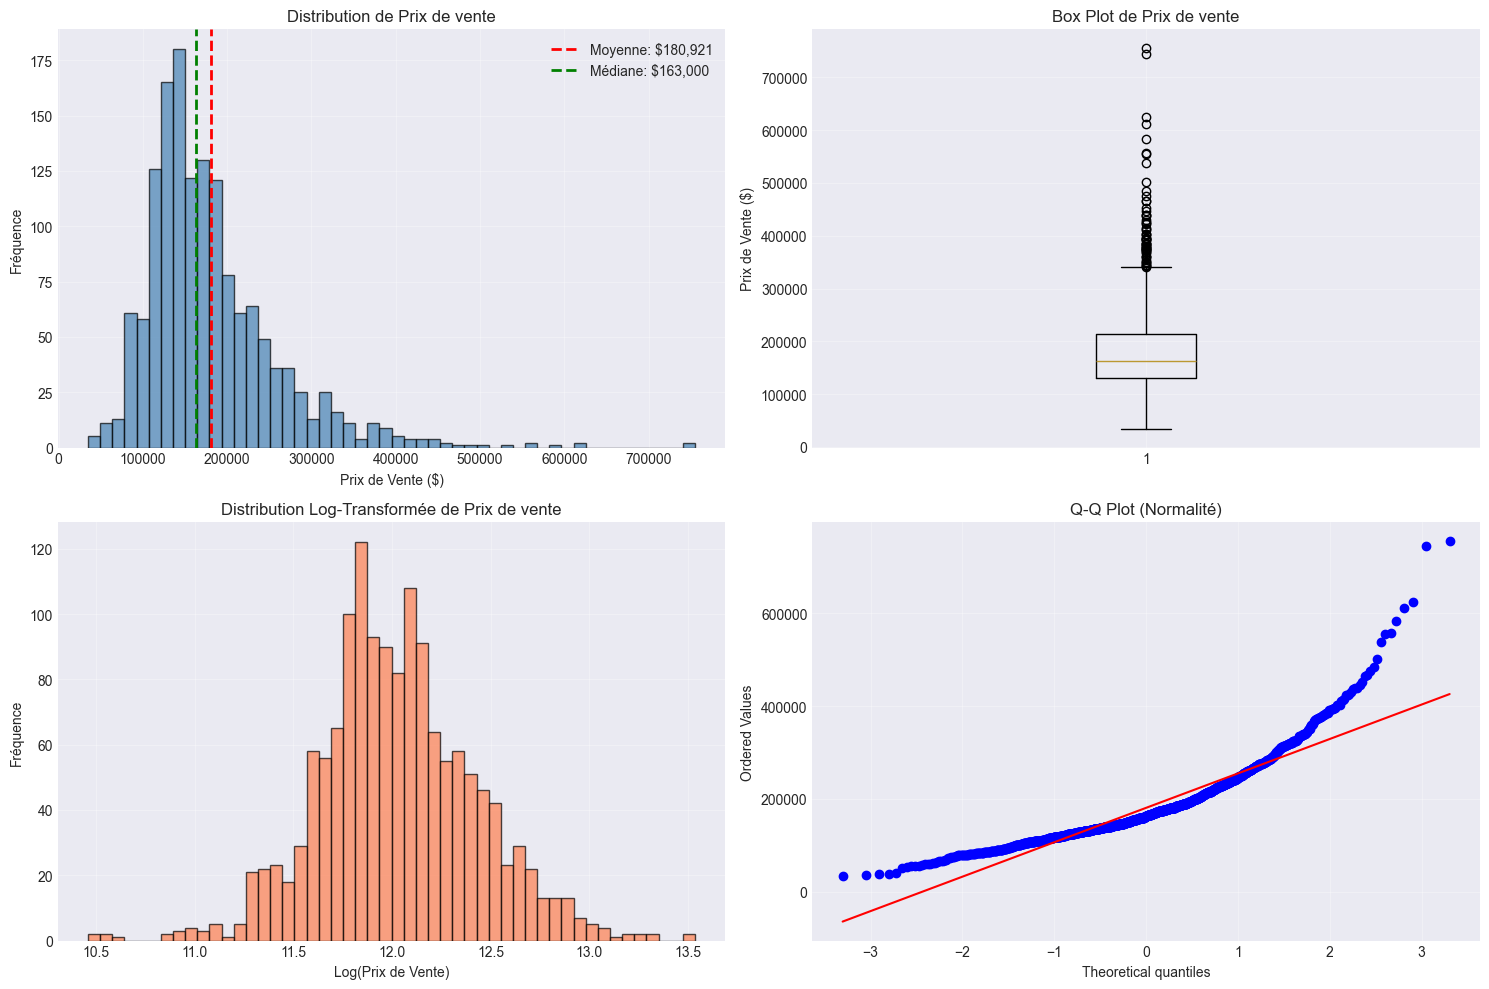


Observation: La distribution est asymetrique a droite
   Une transformation logarithmique peut être bénéfique pour normaliser la distribution.


In [8]:
# Analyse de la variable cible
print("=" * 60)
print("ANALYSE DE LA VARIABLE CIBLE (Prix de vente)")
print("=" * 60)

print("\nStatistiques descriptives:")
print(train_df['prix_de_vente'].describe())

print(f"\nCaracteristiques:")
print(f"   - Minimum: ${train_df['prix_de_vente'].min():,.2f}")
print(f"   - Maximum: ${train_df['prix_de_vente'].max():,.2f}")
print(f"   - Moyenne: ${train_df['prix_de_vente'].mean():,.2f}")
print(f"   - Mediane: ${train_df['prix_de_vente'].median():,.2f}")
print(f"   - Ecart-type: ${train_df['prix_de_vente'].std():,.2f}")

print(f"\nDistribution:")
print(f"   - Skewness: {train_df['prix_de_vente'].skew():.3f} {'(asymétrique à droite)' if train_df['prix_de_vente'].skew() > 0.5 else '(relativement symétrique)'}")
kurtosis_val = train_df['prix_de_vente'].kurtosis()
print(f"   - Kurtosis: {kurtosis_val:.3f}")

# Explication du Kurtosis
print(f"\nInterpretation du Kurtosis:")
print(f"   - Kurtosis = 3: Distribution normale (mesokurtique)")
print(f"   - Kurtosis < 3: Distribution avec queues legeres (platikurtique)")
print(f"   - Kurtosis > 3: Distribution avec queues lourdes (leptokurtique)")
print(f"\n   Notre valeur ({kurtosis_val:.3f}) indique:")
if kurtosis_val > 3:
    print(f"   - Distribution LEPTOKURTIQUE (queues tres lourdes)")
    print(f"   - Presence importante de valeurs extremes (outliers)")
    print(f"   - Distribution plus pointue que la normale")
    print(f"   - Necessite une transformation (logarithmique) pour normaliser")
elif kurtosis_val < 3:
    print(f"   - Distribution PLATIKURTIQUE (queues legeres)")
    print(f"   - Moins de valeurs extremes que la normale")
else:
    print(f"   - Distribution MESOKURTIQUE (normale)")

# Visualisation
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Histogramme
axes[0, 0].hist(train_df['prix_de_vente'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 0].axvline(train_df['prix_de_vente'].mean(), color='r', linestyle='--', linewidth=2, label=f'Moyenne: ${train_df["prix_de_vente"].mean():,.0f}')
axes[0, 0].axvline(train_df['prix_de_vente'].median(), color='g', linestyle='--', linewidth=2, label=f'Médiane: ${train_df["prix_de_vente"].median():,.0f}')
axes[0, 0].set_xlabel('Prix de Vente ($)')
axes[0, 0].set_ylabel('Fréquence')
axes[0, 0].set_title('Distribution de Prix de vente')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Box plot
axes[0, 1].boxplot(train_df['prix_de_vente'], vert=True)
axes[0, 1].set_ylabel('Prix de Vente ($)')
axes[0, 1].set_title('Box Plot de Prix de vente')
axes[0, 1].grid(True, alpha=0.3)

# Distribution log-transformée
axes[1, 0].hist(np.log1p(train_df['prix_de_vente']), bins=50, edgecolor='black', alpha=0.7, color='coral')
axes[1, 0].set_xlabel('Log(Prix de Vente)')
axes[1, 0].set_ylabel('Fréquence')
axes[1, 0].set_title('Distribution Log-Transformée de Prix de vente')
axes[1, 0].grid(True, alpha=0.3)

# Q-Q plot pour vérifier la normalité
from scipy import stats
stats.probplot(train_df['prix_de_vente'], dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot (Normalité)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../output/figures/saleprice_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nObservation: La distribution est {'asymetrique a droite' if train_df['prix_de_vente'].skew() > 0.5 else 'relativement symetrique'}")
print(f"   Une transformation logarithmique peut être bénéfique pour normaliser la distribution.")


In [9]:
# Analyse des valeurs manquantes
print("=" * 60)
print("ANALYSE DES VALEURS MANQUANTES")
print("=" * 60)

missing_train = train_df.isnull().sum()
missing_pct_train = (missing_train / len(train_df)) * 100
missing_df_train = pd.DataFrame({
    'Colonne': missing_train.index,
    'Valeurs_Manquantes': missing_train.values,
    'Pourcentage': missing_pct_train.values
}).sort_values('Valeurs_Manquantes', ascending=False)

missing_df_train = missing_df_train[missing_df_train['Valeurs_Manquantes'] > 0]

print(f"\nColonnes avec valeurs manquantes dans TRAIN: {len(missing_df_train)}")
print(f"\nTop 20 colonnes avec le plus de valeurs manquantes:")
print(missing_df_train.head(20).to_string(index=False))

# Visualisation
if len(missing_df_train) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    
    # Bar plot
    top_missing = missing_df_train.head(15)
    axes[0].barh(range(len(top_missing)), top_missing['Pourcentage'], color='coral')
    axes[0].set_yticks(range(len(top_missing)))
    axes[0].set_yticklabels(top_missing['Colonne'])
    axes[0].set_xlabel('Pourcentage de valeurs manquantes (%)')
    axes[0].set_title('Top 15 Colonnes avec Valeurs Manquantes (Train)')
    axes[0].invert_yaxis()
    axes[0].grid(True, alpha=0.3)
    
    # Heatmap des valeurs manquantes
    missing_cols = missing_df_train.head(20)['Colonne'].tolist()
    missing_matrix = train_df[missing_cols].isnull()
    sns.heatmap(missing_matrix, yticklabels=False, cbar=True, ax=axes[1], cmap='viridis')
    axes[1].set_title('Pattern des Valeurs Manquantes (Top 20)')
    axes[1].set_xlabel('Colonnes')
    
    plt.tight_layout()
    plt.savefig('../output/figures/missing_values_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\nObservations:")
    print(f"   - {len(missing_df_train)} colonnes contiennent des valeurs manquantes")
    print(f"   - La colonne avec le plus de valeurs manquantes: {missing_df_train.iloc[0]['Colonne']} ({missing_df_train.iloc[0]['Pourcentage']:.1f}%)")
else:
    print("\nAucune valeur manquante dans le dataset d'entrainement!")

# Variables sans valeurs manquantes
print("\n" + "=" * 60)
print("VARIABLES SANS VALEURS MANQUANTES")
print("=" * 60)

no_missing = train_df.columns[train_df.isnull().sum() == 0].tolist()
print(f"\nNombre de variables sans valeurs manquantes: {len(no_missing)}")
print(f"Sur un total de {len(train_df.columns)} variables\n")

# Séparer par type
no_missing_numeric = [col for col in no_missing if train_df[col].dtype in ['int64', 'float64']]
no_missing_categorical = [col for col in no_missing if train_df[col].dtype == 'object']

print(f"Variables numeriques sans valeurs manquantes ({len(no_missing_numeric)}):")
for i, col in enumerate(no_missing_numeric, 1):
    print(f"   {i:3d}. {col}")

print(f"\nVariables categorielles sans valeurs manquantes ({len(no_missing_categorical)}):")
for i, col in enumerate(no_missing_categorical, 1):
    print(f"   {i:3d}. {col}")

# Sauvegarder la liste
no_missing_df = pd.DataFrame({
    'Variable': no_missing,
    'Type': ['Numerique' if col in no_missing_numeric else 'Categorielle' for col in no_missing]
})
no_missing_df.to_csv('../output/tables/variables_sans_valeurs_manquantes.csv', index=False)
print(f"\nListe sauvegardee dans: output/tables/variables_sans_valeurs_manquantes.csv")


ANALYSE DES VALEURS MANQUANTES

Colonnes avec valeurs manquantes dans TRAIN: 0

Top 20 colonnes avec le plus de valeurs manquantes:
Empty DataFrame
Columns: [Colonne, Valeurs_Manquantes, Pourcentage]
Index: []

Aucune valeur manquante dans le dataset d'entrainement!

VARIABLES SANS VALEURS MANQUANTES

Nombre de variables sans valeurs manquantes: 81
Sur un total de 81 variables

Variables numeriques sans valeurs manquantes (31):
     1. identifiant
     2. superficie_du_lot_pieds
     3. annee_de_construction
     4. annee_de_renovation
     5. surface_finie_sous_sol
     6. surface_finie_sous_sol_2
     7. surface_non_finie_sous_sol
     8. total_surface_sous_sol
     9. surface_du_premier_etage
    10. surface_du_deuxieme_etage
    11. surface_finie_basse_qualite_pieds
    12. surface_habitable_totale
    13. salles_de_bain_completes_sous_sol
    14. demi_salles_de_bain_sous_sol
    15. salles_de_bain_completes
    16. demi_salles_de_bain
    17. chambres_hors_sous_sol
    18. cuisine

In [10]:
# Catégorisation des variables
print("=" * 60)
print("CATÉGORISATION DES VARIABLES")
print("=" * 60)

# Définir les catégories
categories = {
    'identifiant': ['identifiant'],
    'Caractéristiques Physiques': [
        'type_de_logement', 'facade_en_pieds', 'superficie_du_lot_pieds', 'forme_du_lot', 'topographie_du_terrain', 
        'configuration_du_lot', 'inclinaison_du_terrain', 'surface_du_premier_etage', 'surface_du_deuxieme_etage', 'surface_finie_basse_qualite_pieds', 
        'surface_habitable_totale', 'chambres_hors_sous_sol', 'cuisines_hors_sous_sol', 'total_des_pieces_hors_sous_sol'
    ],
    'Localisation': [
        'zonage_classification', 'type_de_route', 'acces_a_une_allee', 'quartier', 'proximite_1ere_condition', 'proximite_2e_condition'
    ],
    'Type et Style': [
        'type_de_batiment', 'style_de_maison', 'style_de_toit', 'materiau_du_toit', 
        'revetement_exterieur_1', 'revetement_exterieur_2', 'type_de_parement_en_maconnerie', 'surface_de_parement_pieds'
    ],
    'Qualité et Condition': [
        'qualite_globale', 'etat_general', 'qualite_exterieure', 'etat_exterieur', 
        'type_de_fondation', 'qualite_du_sous_sol', 'etat_general_du_sous_sol', 'exposition_du_sous_sol', 
        'type_de_finition_sous_sol_1', 'type_de_finition_sous_sol_2', 'qualite_du_chauffage', 'qualite_de_la_cuisine', 
        'fonctionnalite_globale', 'qualite_de_la_cheminee', 'qualite_du_garage', 'condition_du_garage', 
        'qualite_de_la_piscine', 'cloture'
    ],
    'Sous-sol': [
        'surface_finie_sous_sol', 'surface_finie_sous_sol_2', 'surface_non_finie_sous_sol', 'total_surface_sous_sol', 
        'salles_de_bain_completes_sous_sol', 'demi_salles_de_bain_sous_sol'
    ],
    'Garage': [
        'type_de_garage', 'annee_de_construction_du_garage', 'finition_interieure_du_garage', 
        'capacite_du_garage_voitures', 'surface_du_garage'
    ],
    'Salles de bain': [
        'salles_de_bain_completes', 'demi_salles_de_bain'
    ],
    'Systèmes': [
        'services_publics_disponibles', 'type_de_chauffage', 'climatisation_centrale', 'systeme_electrique', 'allee_pavee'
    ],
    'Extérieur': [
        'surface_du_deck_en_bois', 'surface_du_porche_ouvert', 'porche_ferme', 
        'porche_trois_saisons', 'porche_screen', 'surface_de_la_piscine_pieds'
    ],
    'Divers': [
        'nombre_de_cheminees', 'caracteristiques_supplementaires', 'valeur_des_caracteristiques_supplementaires'
    ],
    'Temporel': [
        'annee_de_construction', 'annee_de_renovation', 'mois_de_vente', 'annee_de_vente'
    ],
    'Transaction': [
        'type_de_vente', 'condition_de_la_vente'
    ],
    'Cible': [
        'prix_de_vente'
    ]
}

print("\nRepartition des variables par categorie:\n")
for category, vars_list in categories.items():
    existing_vars = [v for v in vars_list if v in train_df.columns]
    if existing_vars:
        print(f"   {category}: {len(existing_vars)} variables")
        print(f"      {', '.join(existing_vars[:5])}")
        if len(existing_vars) > 5:
            print(f"      ... et {len(existing_vars) - 5} autres")
        print()


CATÉGORISATION DES VARIABLES

Repartition des variables par categorie:

   identifiant: 1 variables
      identifiant

   Caractéristiques Physiques: 14 variables
      type_de_logement, facade_en_pieds, superficie_du_lot_pieds, forme_du_lot, topographie_du_terrain
      ... et 9 autres

   Localisation: 6 variables
      zonage_classification, type_de_route, acces_a_une_allee, quartier, proximite_1ere_condition
      ... et 1 autres

   Type et Style: 8 variables
      type_de_batiment, style_de_maison, style_de_toit, materiau_du_toit, revetement_exterieur_1
      ... et 3 autres

   Qualité et Condition: 18 variables
      qualite_globale, etat_general, qualite_exterieure, etat_exterieur, type_de_fondation
      ... et 13 autres

   Sous-sol: 6 variables
      surface_finie_sous_sol, surface_finie_sous_sol_2, surface_non_finie_sous_sol, total_surface_sous_sol, salles_de_bain_completes_sous_sol
      ... et 1 autres

   Garage: 5 variables
      type_de_garage, annee_de_construction_d

## 6. Variables Numériques Clés


VARIABLES NUMÉRIQUES CLÉS

Statistiques descriptives des variables cles:

       surface_habitable_totale  total_surface_sous_sol  \
count                   1460.00                 1460.00   
mean                    1515.46                 1057.43   
std                      525.48                  438.71   
min                      334.00                    0.00   
25%                     1129.50                  795.75   
50%                     1464.00                  991.50   
75%                     1776.75                 1298.25   
max                     5642.00                 6110.00   

       superficie_du_lot_pieds  annee_de_construction  surface_du_garage  \
count                  1460.00                1460.00            1460.00   
mean                  10516.83                1971.27             472.98   
std                    9981.26                  30.20             213.80   
min                    1300.00                1872.00               0.00   
25%           

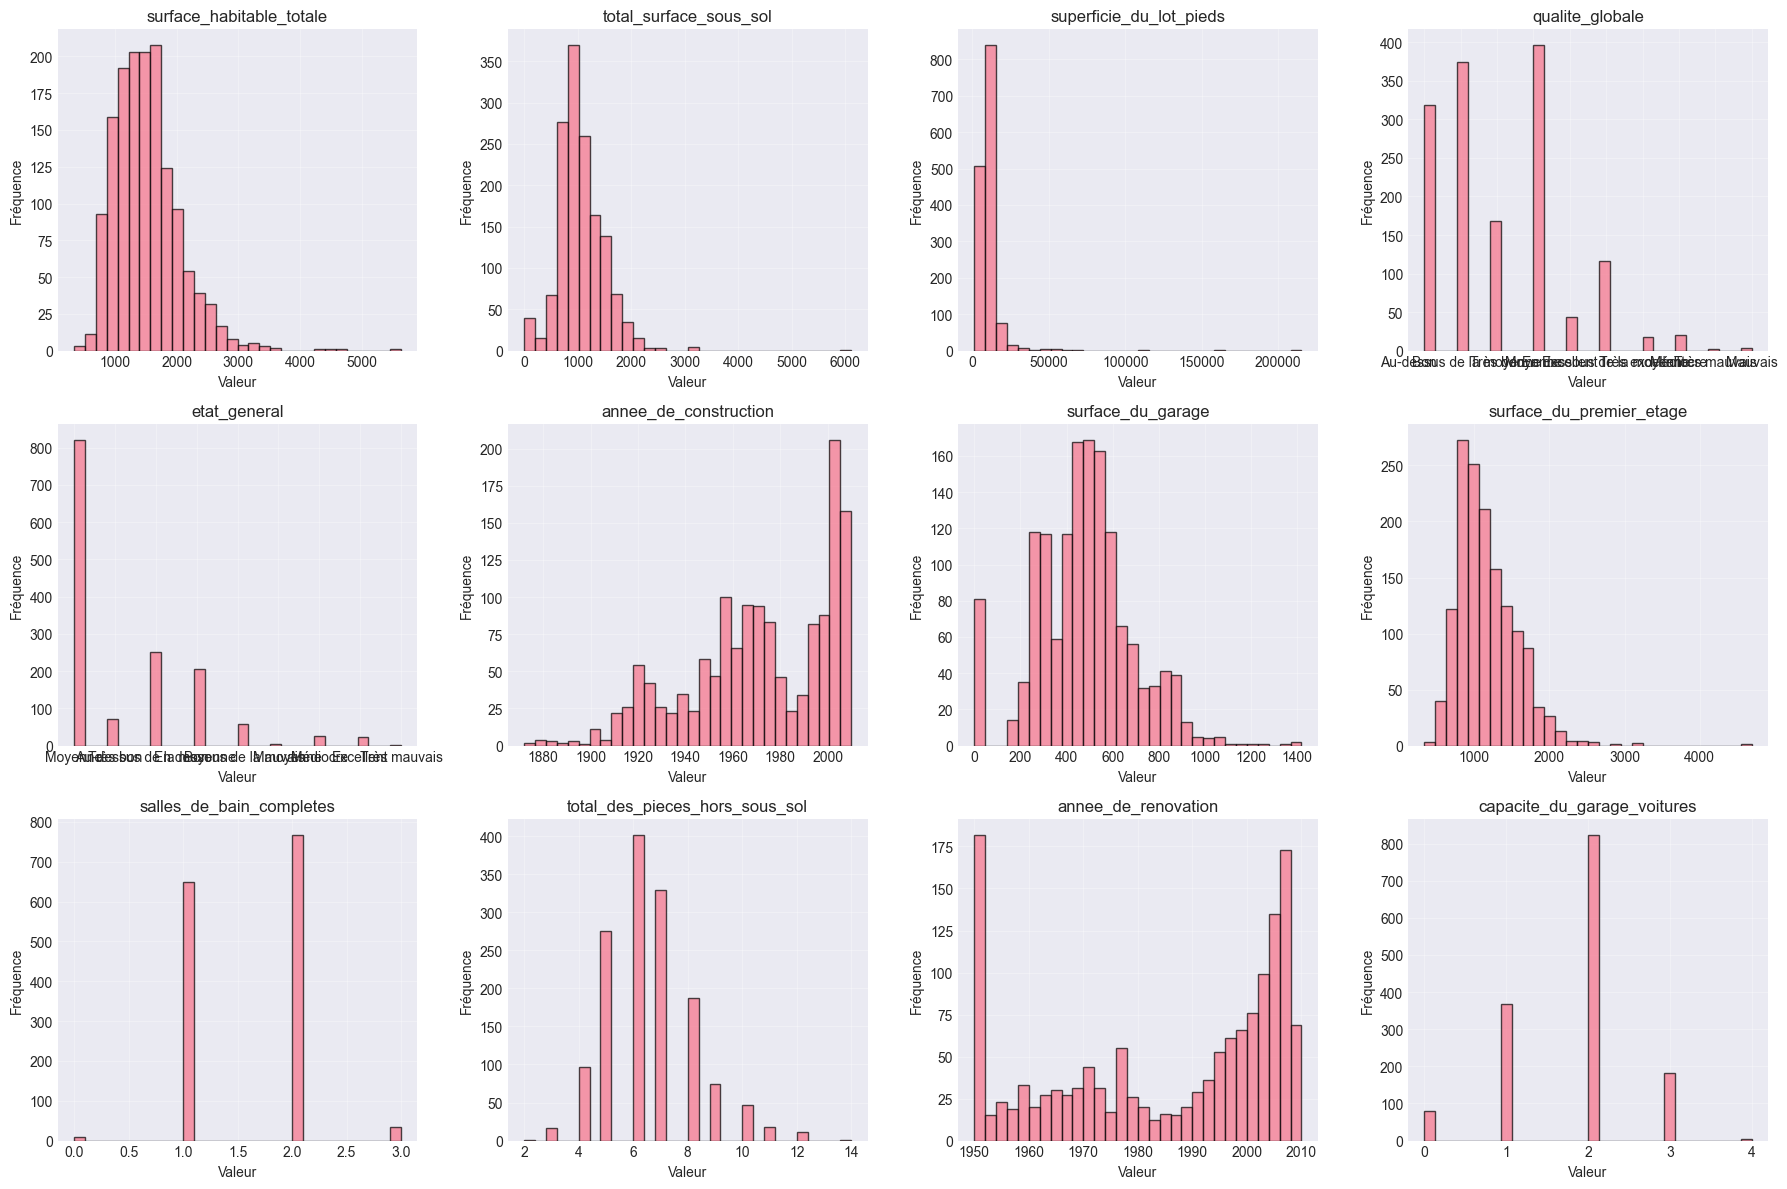

In [11]:
# Analyse des variables numériques importantes
print("=" * 60)
print("VARIABLES NUMÉRIQUES CLÉS")
print("=" * 60)

key_numeric_vars = ['surface_habitable_totale', 'total_surface_sous_sol', 'superficie_du_lot_pieds', 'qualite_globale', 
                     'etat_general', 'annee_de_construction', 'surface_du_garage', 'surface_du_premier_etage', 
                     'salles_de_bain_completes', 'total_des_pieces_hors_sous_sol', 'annee_de_renovation', 'capacite_du_garage_voitures']

existing_key_vars = [v for v in key_numeric_vars if v in train_df.columns]

print("\nStatistiques descriptives des variables cles:\n")
print(train_df[existing_key_vars].describe().round(2))

# Visualisation des distributions
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for idx, var in enumerate(existing_key_vars[:12]):
    axes[idx].hist(train_df[var].dropna(), bins=30, edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'{var}')
    axes[idx].set_xlabel('Valeur')
    axes[idx].set_ylabel('Fréquence')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../output/figures/key_numeric_vars_distributions.png', dpi=300, bbox_inches='tight')
plt.show()


## 7. Variables Catégorielles Clés


VARIABLES CATÉGORIELLES CLÉS

zonage_classification:
   Nombre de catégories: 5
   Top 5 valeurs:
      Résidentiel basse densité: 1151 (78.8%)
      Résidentiel densité moyenne: 218 (14.9%)
      Résidentiel flottant: 65 (4.5%)
      Résidentiel haute densité: 16 (1.1%)
      Commercial: 10 (0.7%)


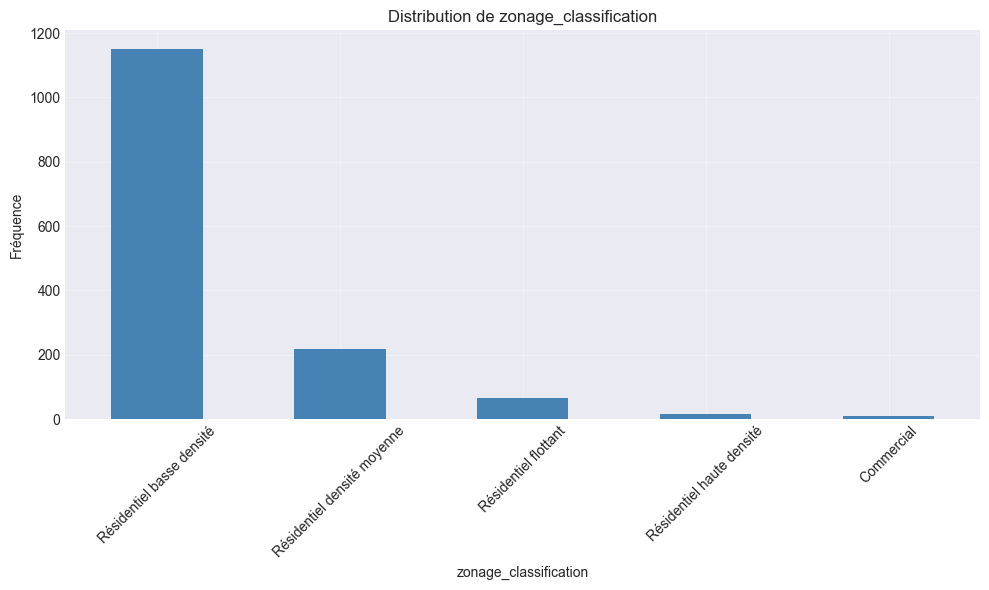


quartier:
   Nombre de catégories: 25
   Top 5 valeurs:
      North Ames: 225 (15.4%)
      College Creek: 150 (10.3%)
      Vieille Ville: 113 (7.7%)
      Edwards: 100 (6.8%)
      Somerset: 86 (5.9%)

type_de_batiment:
   Nombre de catégories: 5
   Top 5 valeurs:
      Maison individuelle: 1220 (83.6%)
      Maison de ville (bout): 114 (7.8%)
      Duplex: 52 (3.6%)
      Maison de ville (intérieur): 43 (2.9%)
      Conversion deux familles: 31 (2.1%)


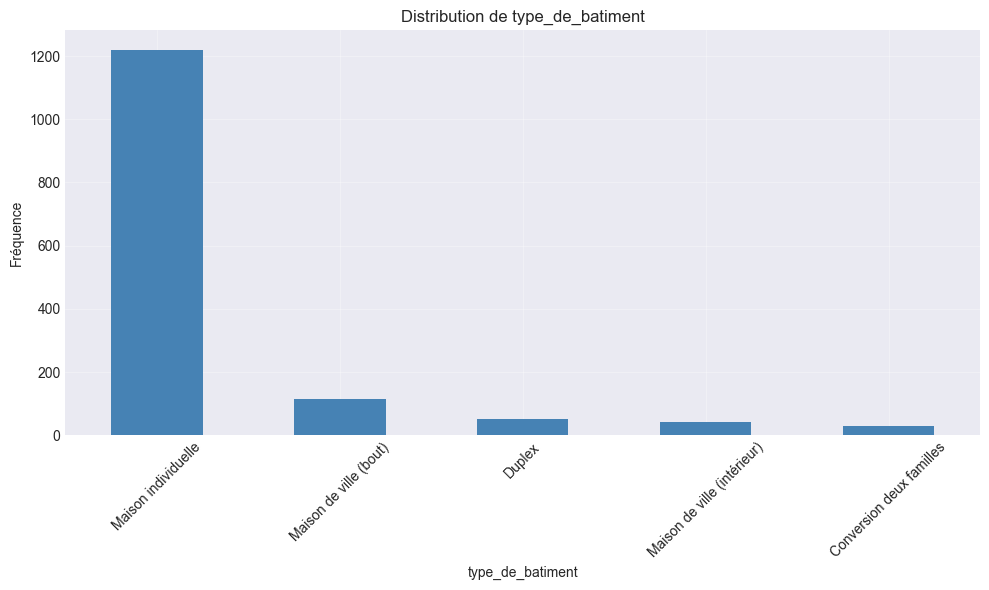


style_de_maison:
   Nombre de catégories: 8
   Top 5 valeurs:
      Un étage: 726 (49.7%)
      Deux étages: 445 (30.5%)
      Un étage et demi, aménagé: 154 (10.5%)
      Niveaux divisés: 65 (4.5%)
      Foyer divisé: 37 (2.5%)


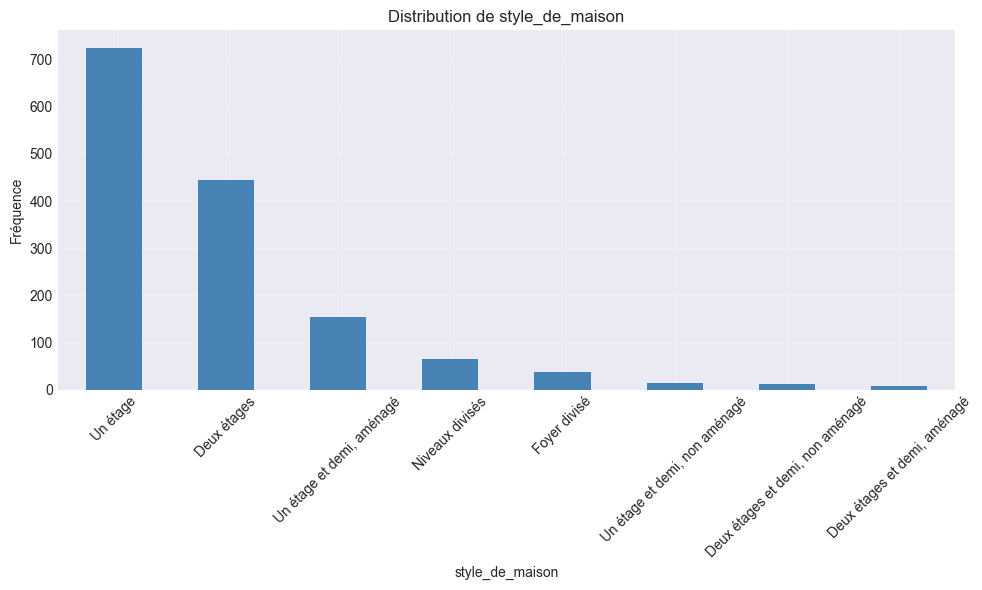


qualite_exterieure:
   Nombre de catégories: 4
   Top 5 valeurs:
      Moyen: 906 (62.1%)
      Bon: 488 (33.4%)
      Excellent: 52 (3.6%)
      Médiocre: 14 (1.0%)


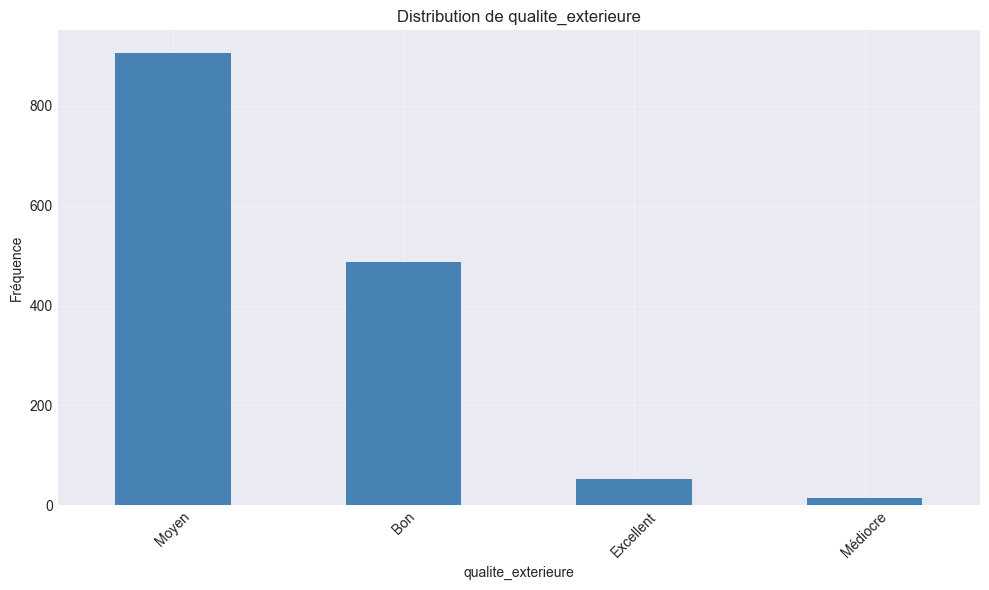


qualite_de_la_cuisine:
   Nombre de catégories: 4
   Top 5 valeurs:
      Moyen: 735 (50.3%)
      Bon: 586 (40.1%)
      Excellent: 100 (6.8%)
      Médiocre: 39 (2.7%)


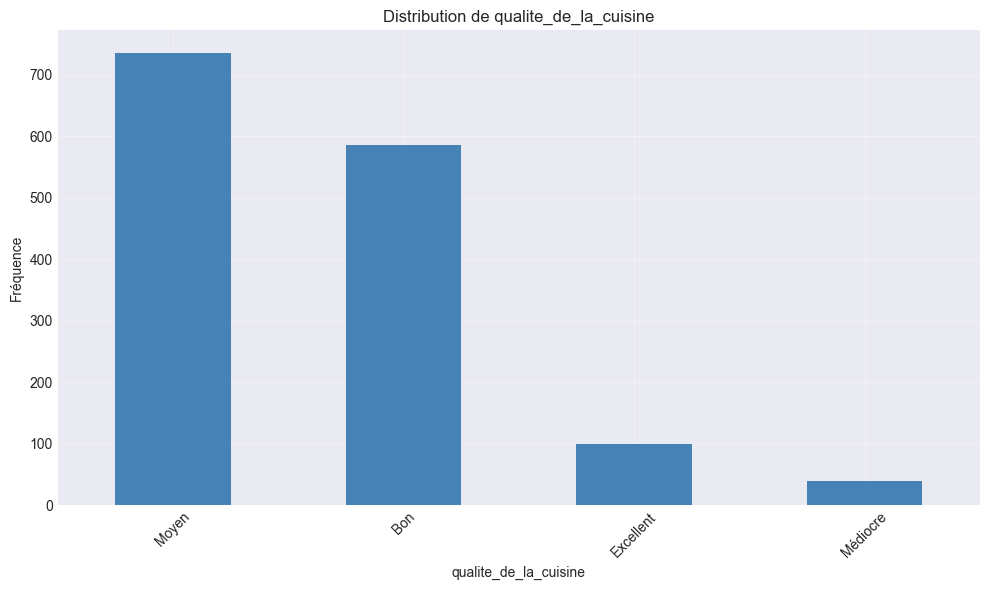


type_de_vente:
   Nombre de catégories: 9
   Top 5 valeurs:
      Acte de garantie - Conventionnel: 1267 (86.8%)
      Maison neuve construite et vendue: 122 (8.4%)
      Acte de l'officier judiciaire/Etat: 43 (2.9%)
      Contrat - Acompte faible: 9 (0.6%)
      Contrat - Faible taux d'intérêt: 5 (0.3%)


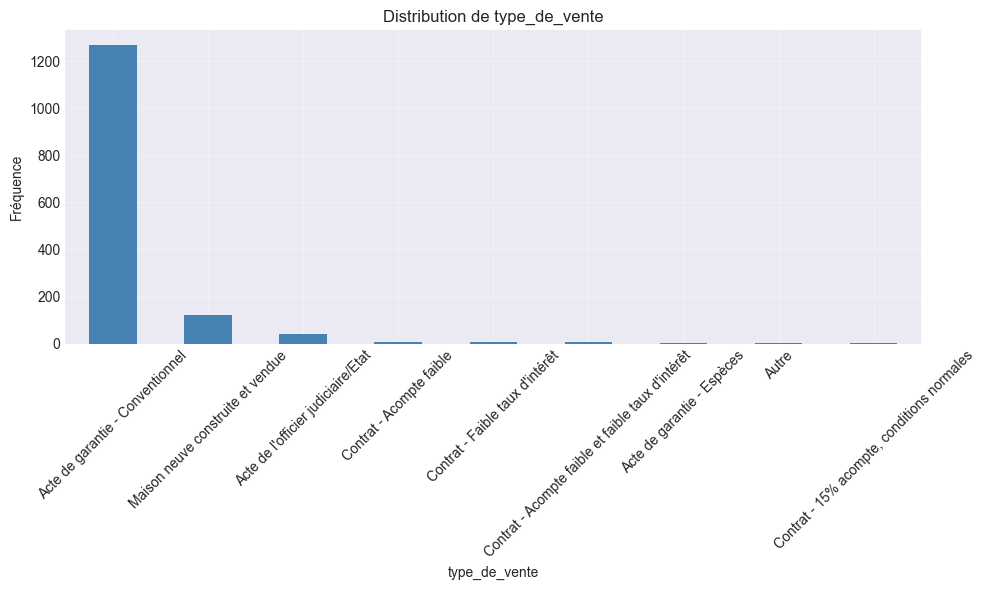


condition_de_la_vente:
   Nombre de catégories: 6
   Top 5 valeurs:
      Vente normale: 1198 (82.1%)
      Maison incomplète: 125 (8.6%)
      Vente anormale: 101 (6.9%)
      Vente entre membres de la famille: 20 (1.4%)
      Allocation (propriétés liées): 12 (0.8%)


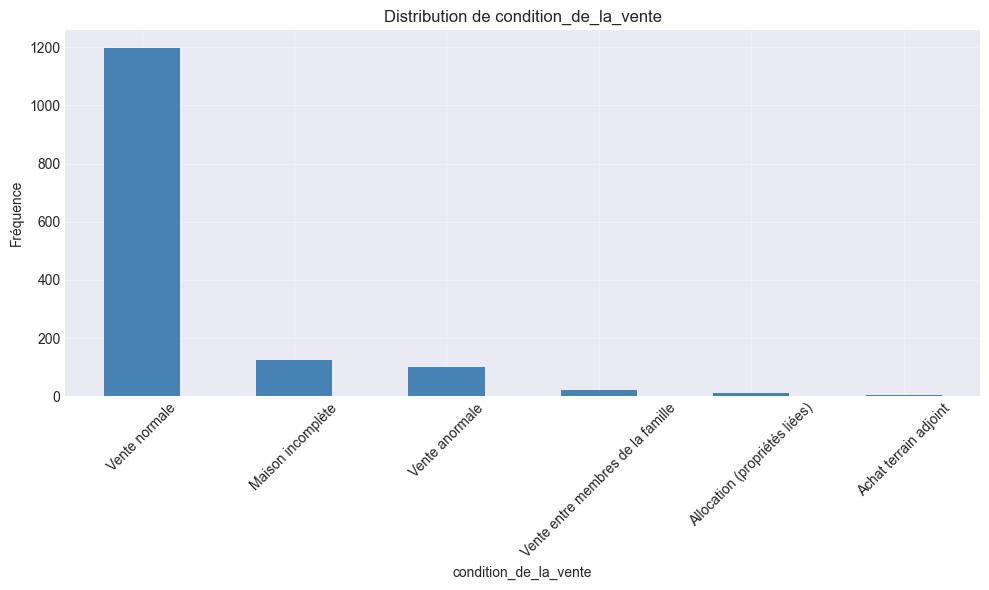

In [12]:
# Analyse des variables catégorielles importantes
print("=" * 60)
print("VARIABLES CATÉGORIELLES CLÉS")
print("=" * 60)

key_categorical_vars = ['zonage_classification', 'quartier', 'type_de_batiment', 'style_de_maison', 
                        'qualite_exterieure', 'qualite_de_la_cuisine', 'type_de_vente', 'condition_de_la_vente']

existing_cat_vars = [v for v in key_categorical_vars if v in train_df.columns]

for var in existing_cat_vars:
    print(f"\n{var}:")
    value_counts = train_df[var].value_counts()
    print(f"   Nombre de catégories: {train_df[var].nunique()}")
    print(f"   Top 5 valeurs:")
    for val, count in value_counts.head().items():
        pct = (count / len(train_df)) * 100
        print(f"      {val}: {count} ({pct:.1f}%)")
    
    # Visualisation
    if train_df[var].nunique() <= 20:  # Seulement si pas trop de catégories
        fig, ax = plt.subplots(figsize=(10, 6))
        value_counts.head(10).plot(kind='bar', ax=ax, color='steelblue')
        ax.set_title(f'Distribution de {var}')
        ax.set_xlabel(var)
        ax.set_ylabel('Fréquence')
        ax.tick_params(axis='x', rotation=45)
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(f'../output/figures/categorical_{var}.png', dpi=300, bbox_inches='tight')
        plt.show()


## 11. Analyses temporelle et géographique 

Cette section:
- Analyse temporelle des prix (évolution par année/mois)
- Analyse géographique par quartier
- Analyse de segments de marché



1. ANALYSE TEMPORELLE DES PRIX

Évolution des prix par année de vente:
                     mean    median       std  count
annee_de_vente                                      
2006            182549.46  163995.0  79426.84    314
2007            186063.15  167000.0  85768.17    329
2008            177360.84  164000.0  69735.61    304
2009            179432.10  162000.0  80879.24    338
2010            177393.67  155000.0  80451.28    175

Évolution des prix par mois de vente:
                    mean    median        std  count
mois_de_vente                                       
Janvier        183256.26  151650.0  121381.08     58
Février        177882.00  173250.0   52960.86     52
Mars           183253.92  165250.0   86488.45    106
Avril          171503.26  147000.0   77147.32    141
Mai            172307.27  154000.0   68614.55    204
Juin           177395.74  163000.0   69453.09    253
Juillet        186331.19  165195.0   91772.13    234
Août           184651.83  174450.0   7321

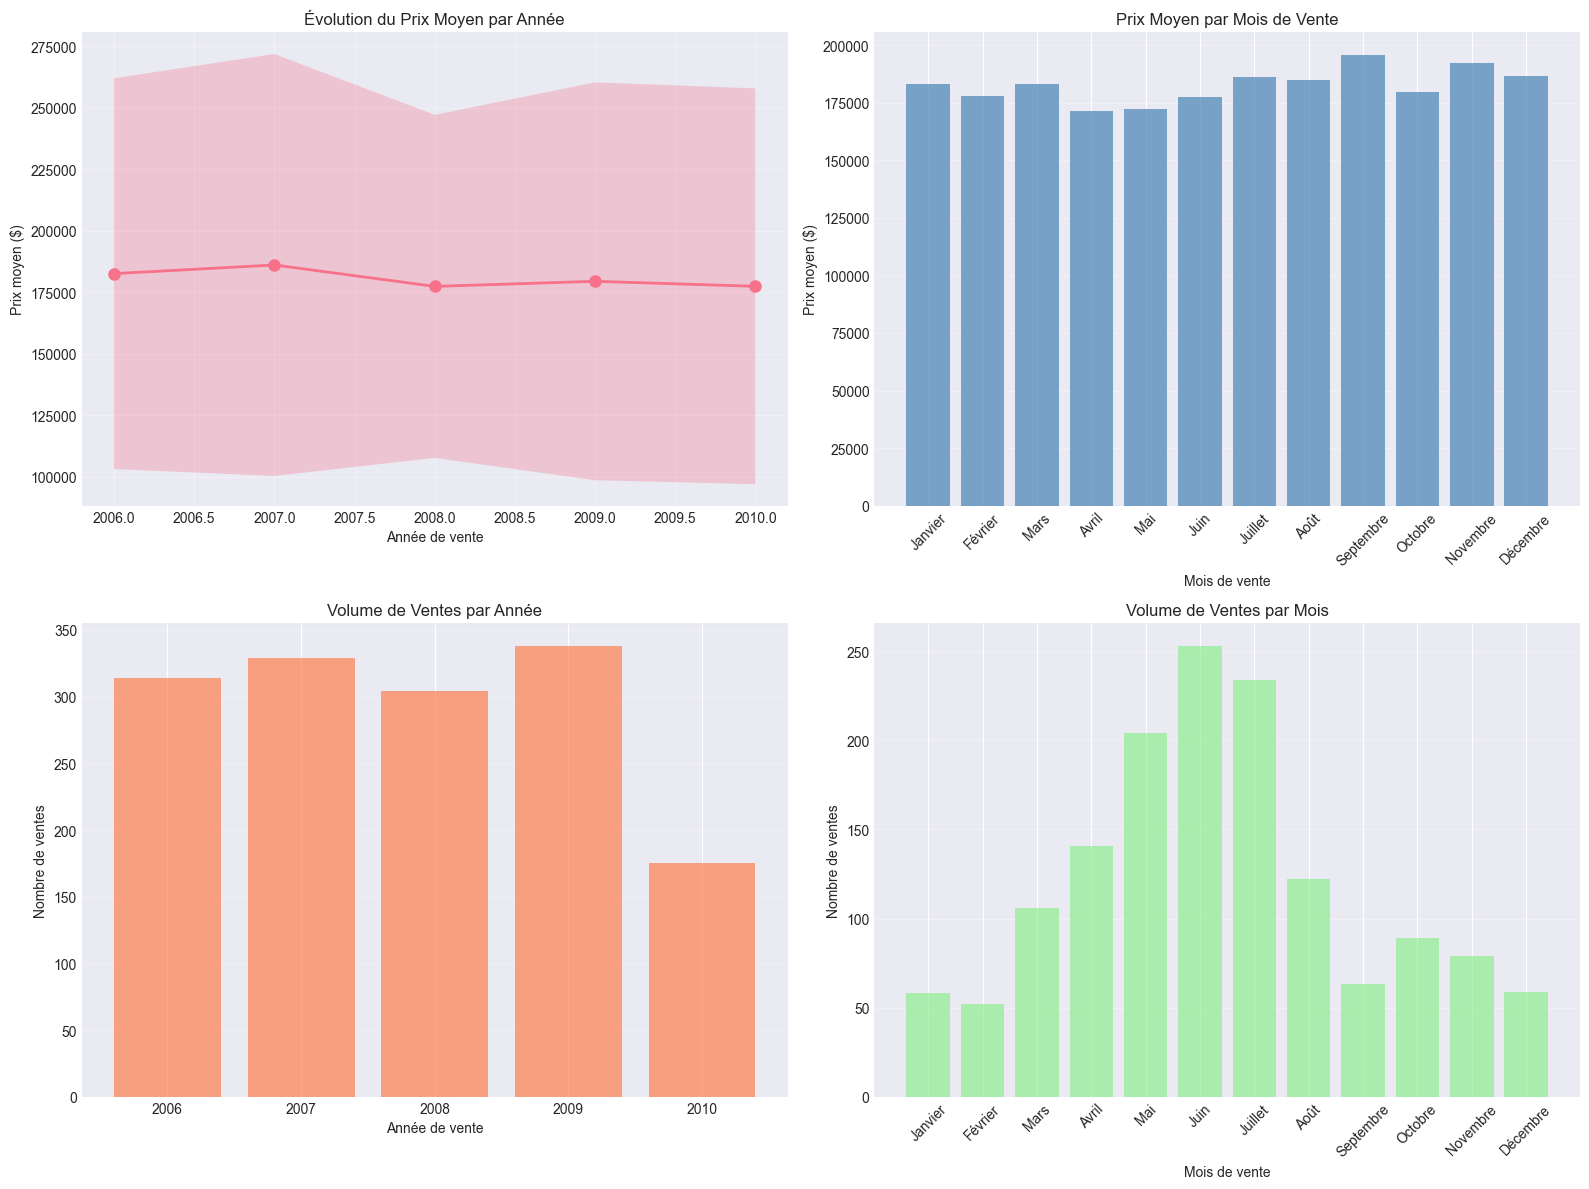


Corrélation entre année de vente et prix: -0.029


In [13]:
# ============================================================================
# 1. ANALYSE TEMPORELLE DES PRIX
# ============================================================================
# Technique : Analyse de l'évolution des prix par année et mois de vente
# Objectif : Identifier des tendances temporelles et saisonnalité

print("\n" + "=" * 60)
print("1. ANALYSE TEMPORELLE DES PRIX")
print("=" * 60)

if 'annee_de_vente' in train_df.columns and 'mois_de_vente' in train_df.columns:
    # Analyser l'évolution des prix par année
    prix_par_annee = train_df.groupby('annee_de_vente')['prix_de_vente'].agg(['mean', 'median', 'std', 'count'])
    
    print("\nÉvolution des prix par année de vente:")
    print(prix_par_annee.round(2))
    
    # Analyser l'évolution des prix par mois
    prix_par_mois = train_df.groupby('mois_de_vente')['prix_de_vente'].agg(['mean', 'median', 'std', 'count'])
    
    # Ordre chronologique des mois en français
    ordre_mois = ['Janvier', 'Février', 'Mars', 'Avril', 'Mai', 'Juin', 
                  'Juillet', 'Août', 'Septembre', 'Octobre', 'Novembre', 'Décembre']
    
    # Réordonner selon l'ordre chronologique (garder seulement les mois présents)
    mois_presents = [m for m in ordre_mois if m in prix_par_mois.index]
    prix_par_mois = prix_par_mois.reindex(mois_presents)
    
    print("\nÉvolution des prix par mois de vente:")
    print(prix_par_mois.round(2))
    
    # Visualisation
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Prix moyen par année
    axes[0, 0].plot(prix_par_annee.index, prix_par_annee['mean'], marker='o', linewidth=2, markersize=8)
    axes[0, 0].fill_between(prix_par_annee.index, 
                            prix_par_annee['mean'] - prix_par_annee['std'],
                            prix_par_annee['mean'] + prix_par_annee['std'],
                            alpha=0.3)
    axes[0, 0].set_xlabel('Année de vente')
    axes[0, 0].set_ylabel('Prix moyen ($)')
    axes[0, 0].set_title('Évolution du Prix Moyen par Année')
    axes[0, 0].grid(True, alpha=0.3)
    
    # Prix moyen par mois
    # Utiliser les noms de mois complets dans l'ordre chronologique
    axes[0, 1].bar(range(len(prix_par_mois)), prix_par_mois['mean'], color='steelblue', alpha=0.7)
    axes[0, 1].set_xlabel('Mois de vente')
    axes[0, 1].set_ylabel('Prix moyen ($)')
    axes[0, 1].set_title('Prix Moyen par Mois de Vente')
    axes[0, 1].set_xticks(range(len(prix_par_mois)))
    axes[0, 1].set_xticklabels(prix_par_mois.index, rotation=45)
    axes[0, 1].grid(True, alpha=0.3, axis='y')
    
    # Nombre de ventes par année
    axes[1, 0].bar(prix_par_annee.index, prix_par_annee['count'], color='coral', alpha=0.7)
    axes[1, 0].set_xlabel('Année de vente')
    axes[1, 0].set_ylabel('Nombre de ventes')
    axes[1, 0].set_title('Volume de Ventes par Année')
    axes[1, 0].grid(True, alpha=0.3, axis='y')
    
    # Nombre de ventes par mois
    axes[1, 1].bar(range(len(prix_par_mois)), prix_par_mois['count'], color='lightgreen', alpha=0.7)
    axes[1, 1].set_xlabel('Mois de vente')
    axes[1, 1].set_ylabel('Nombre de ventes')
    axes[1, 1].set_title('Volume de Ventes par Mois')
    axes[1, 1].set_xticks(range(len(prix_par_mois)))
    axes[1, 1].set_xticklabels(prix_par_mois.index, rotation=45)
    axes[1, 1].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig('../output/figures/temporal_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Test de corrélation entre année et prix
    if len(prix_par_annee) > 1:
        corr_annee_prix = train_df[['annee_de_vente', 'prix_de_vente']].corr().iloc[0, 1]
        print(f"\nCorrélation entre année de vente et prix: {corr_annee_prix:.3f}")
        
        # Test de saisonnalité (ANOVA entre mois)
        from scipy.stats import f_oneway
        mois_groups = [train_df[train_df['mois_de_vente'] == m]['prix_de_vente'].dropna() 
                      for m in range(1, 13) if len(train_df[train_df['mois_de_vente'] == m]) > 0]
        if len(mois_groups) > 1:
            f_stat, p_val = f_oneway(*mois_groups)
            print(f"Test ANOVA pour saisonnalité (mois): F={f_stat:.3f}, p={p_val:.4f}")
            if p_val < 0.05:
                print("   → Saisonnalité significative détectée!")
            else:
                print("   → Pas de saisonnalité significative")
else:
    print("\nVariables temporelles (annee_de_vente, mois_de_vente) non disponibles")



2. ANALYSE GÉOGRAPHIQUE PAR QUARTIER

Statistiques des prix par quartier (25 quartiers):
                                               count       mean    median  \
quartier                                                                    
Northridge                                        41  335295.32  301500.0   
Northridge Heights                                77  316270.62  315000.0   
Stone Brook                                       25  310499.00  278000.0   
Timberland                                        38  242247.45  228475.0   
Veenker                                           11  238772.73  218000.0   
Somerset                                          86  225379.84  225500.0   
Clear Creek                                       28  212565.43  200250.0   
Crawford                                          51  210624.73  200624.0   
College Creek                                    150  197965.77  197200.0   
Bloomington Heights                               17  194870.88

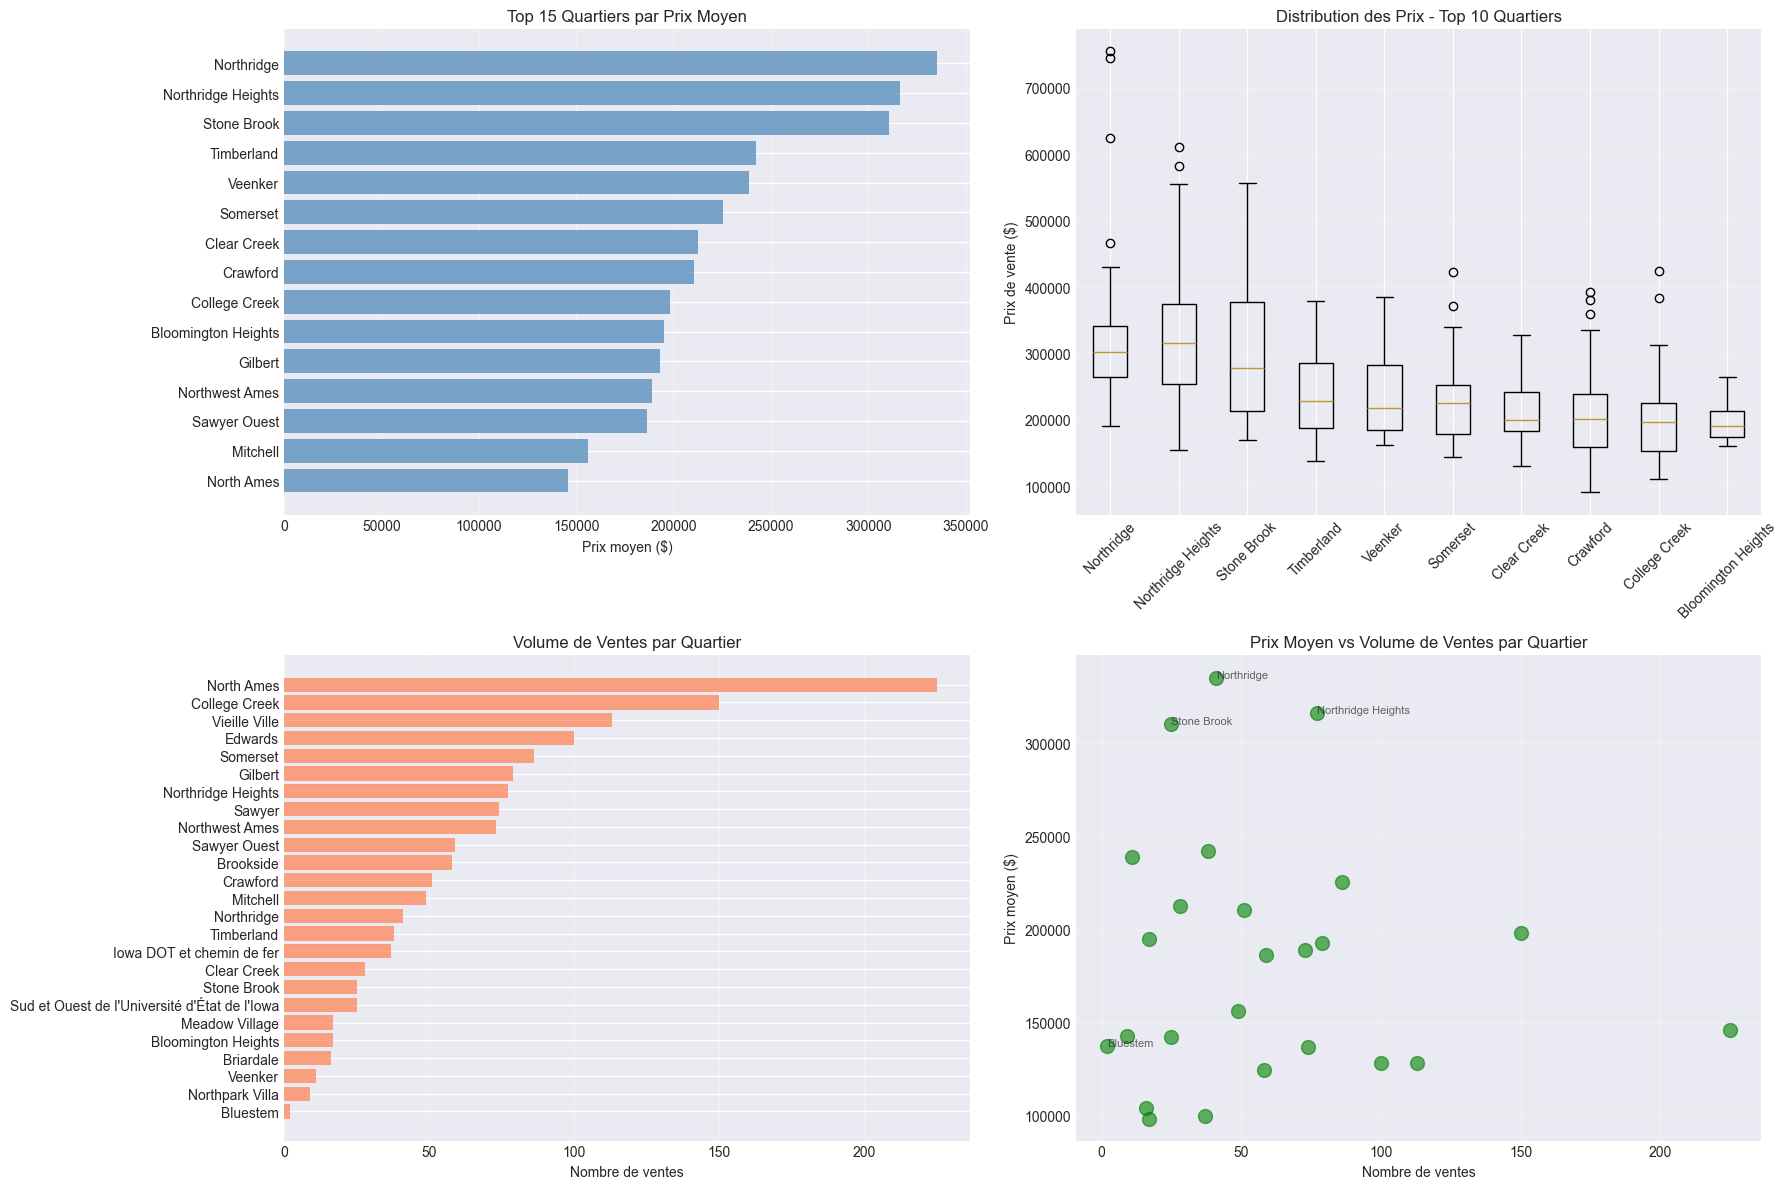


CARACTÉRISTIQUES DES QUARTIERS PREMIUM (Top 5)

Northridge:
   qualite_globale               : 7.93 (moyenne convertie)
   surface_habitable_totale      : 2508.85
   annee_de_construction         : 1995.44

Northridge Heights:
   qualite_globale               : 8.26 (moyenne convertie)
   surface_habitable_totale      : 1915.95
   annee_de_construction         : 2005.68

Stone Brook:
   qualite_globale               : 8.16 (moyenne convertie)
   surface_habitable_totale      : 1879.08
   annee_de_construction         : 1998.48

Timberland:
   qualite_globale               : 7.16 (moyenne convertie)
   surface_habitable_totale      : 1749.37
   annee_de_construction         : 1992.84

Veenker:
   qualite_globale               : 6.73 (moyenne convertie)
   surface_habitable_totale      : 1539.64
   annee_de_construction         : 1982.36


In [14]:
# ============================================================================
# 2. ANALYSE GÉOGRAPHIQUE PAR QUARTIER
# ============================================================================
# Technique : Analyse des prix et caractéristiques par quartier
# Objectif : Identifier les quartiers premium et leurs caractéristiques

print("\n" + "=" * 60)
print("2. ANALYSE GÉOGRAPHIQUE PAR QUARTIER")
print("=" * 60)

if 'quartier' in train_df.columns:
    # Statistiques par quartier
    quartier_stats = train_df.groupby('quartier')['prix_de_vente'].agg([
        'count', 'mean', 'median', 'std', 'min', 'max'
    ]).sort_values('mean', ascending=False)
    
    print(f"\nStatistiques des prix par quartier ({len(quartier_stats)} quartiers):")
    print(quartier_stats.round(2))
    
    # Top 10 et Bottom 10 quartiers par prix moyen
    print("\n" + "=" * 60)
    print("TOP 10 QUARTIERS LES PLUS CHERS")
    print("=" * 60)
    top_10_quartiers = quartier_stats.head(10)
    for idx, (quartier, row) in enumerate(top_10_quartiers.iterrows(), 1):
        print(f"{idx:2d}. {quartier:30s}: ${row['mean']:,.0f} (moyenne), {row['count']} ventes")
    
    print("\n" + "=" * 60)
    print("TOP 10 QUARTIERS LES MOINS CHERS")
    print("=" * 60)
    bottom_10_quartiers = quartier_stats.tail(10)
    for idx, (quartier, row) in enumerate(bottom_10_quartiers.iterrows(), 1):
        print(f"{idx:2d}. {quartier:30s}: ${row['mean']:,.0f} (moyenne), {row['count']} ventes")
    
    # Visualisation
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    
    # Prix moyen par quartier (top 15)
    top_15 = quartier_stats.head(15).sort_values('mean', ascending=True)
    axes[0, 0].barh(range(len(top_15)), top_15['mean'], color='steelblue', alpha=0.7)
    axes[0, 0].set_yticks(range(len(top_15)))
    axes[0, 0].set_yticklabels(top_15.index)
    axes[0, 0].set_xlabel('Prix moyen ($)')
    axes[0, 0].set_title('Top 15 Quartiers par Prix Moyen')
    axes[0, 0].grid(True, alpha=0.3, axis='x')
    
    # Distribution des prix par quartier (boxplot pour top 10)
    top_10_names = top_10_quartiers.index.tolist()
    data_to_plot = [train_df[train_df['quartier'] == q]['prix_de_vente'].dropna() 
                    for q in top_10_names]
    axes[0, 1].boxplot(data_to_plot, labels=top_10_names)
    axes[0, 1].set_ylabel('Prix de vente ($)')
    axes[0, 1].set_title('Distribution des Prix - Top 10 Quartiers')
    axes[0, 1].tick_params(axis='x', rotation=45)
    axes[0, 1].grid(True, alpha=0.3, axis='y')
    
    # Nombre de ventes par quartier
    axes[1, 0].barh(range(len(quartier_stats)), quartier_stats['count'].sort_values(ascending=True), 
                    color='coral', alpha=0.7)
    axes[1, 0].set_yticks(range(len(quartier_stats)))
    axes[1, 0].set_yticklabels(quartier_stats.sort_values('count', ascending=True).index)
    axes[1, 0].set_xlabel('Nombre de ventes')
    axes[1, 0].set_title('Volume de Ventes par Quartier')
    axes[1, 0].grid(True, alpha=0.3, axis='x')
    
    # Relation prix moyen vs nombre de ventes
    axes[1, 1].scatter(quartier_stats['count'], quartier_stats['mean'], 
                      s=100, alpha=0.6, color='green')
    axes[1, 1].set_xlabel('Nombre de ventes')
    axes[1, 1].set_ylabel('Prix moyen ($)')
    axes[1, 1].set_title('Prix Moyen vs Volume de Ventes par Quartier')
    axes[1, 1].grid(True, alpha=0.3)
    
    # Ajouter les noms des quartiers extrêmes
    for idx, row in quartier_stats.iterrows():
        if row['mean'] > quartier_stats['mean'].quantile(0.9) or row['count'] < 5:
            axes[1, 1].annotate(idx, (row['count'], row['mean']), 
                               fontsize=8, alpha=0.7)
    
    plt.tight_layout()
    plt.savefig('../output/figures/geographic_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Analyse des caractéristiques des quartiers premium
    print("\n" + "=" * 60)
    print("CARACTÉRISTIQUES DES QUARTIERS PREMIUM (Top 5)")
    print("=" * 60)
    top_5_quartiers = quartier_stats.head(5).index.tolist()
    
    key_features = ['qualite_globale', 'surface_habitable_totale', 'annee_de_construction']
    key_features = [f for f in key_features if f in train_df.columns]
    
    # Mapping pour convertir qualite_globale en nombre si nécessaire
    qualite_mapping = {
        "Très excellent": 10, "Excellent": 9, "Très bon": 8, "Bon": 7,
        "Au-dessus de la moyenne": 6, "Moyenne": 5, "En dessous de la moyenne": 4,
        "Médiocre": 3, "Mauvais": 2, "Très mauvais": 1
    }
    
    for quartier in top_5_quartiers:
        quartier_data = train_df[train_df['quartier'] == quartier]
        print(f"\n{quartier}:")
        for feat in key_features:
            if feat in quartier_data.columns:
                # Vérifier si c'est une variable numérique ou catégorielle
                if quartier_data[feat].dtype in ['int64', 'float64']:
                    # Variable numérique : calculer la moyenne
                    mean_val = quartier_data[feat].mean()
                    print(f"   {feat:30s}: {mean_val:.2f}")
                else:
                    # Variable catégorielle : convertir en nombre pour qualite_globale
                    if feat == 'qualite_globale':
                        # Convertir en nombre pour la moyenne
                        qualite_num = quartier_data[feat].apply(
                            lambda x: qualite_mapping.get(x, 5) if isinstance(x, str) else x
                        )
                        mean_val = qualite_num.mean()
                        print(f"   {feat:30s}: {mean_val:.2f} (moyenne convertie)")
                    else:
                        # Pour les autres catégorielles, afficher le mode
                        mode_val = quartier_data[feat].mode()
                        if len(mode_val) > 0:
                            print(f"   {feat:30s}: {mode_val.iloc[0]} (mode)")
                        else:
                            print(f"   {feat:30s}: N/A")
else:
    print("\nVariable 'quartier' non disponible")


In [15]:
# ============================================================================
# 4. ANALYSE DE SEGMENTS DE MARCHÉ
# ============================================================================
# Distribution des prix par quartiles

print("\n" + "=" * 60)
print("4. ANALYSE DE SEGMENTS DE MARCHÉ")
print("=" * 60)

if 'prix_de_vente' in train_df.columns:
    # Calculer les quartiles du prix
    price_quartiles = train_df['prix_de_vente'].quantile([0.25, 0.5, 0.75])
    
    print("\nQuartiles des prix de vente:")
    print(f"   Q1 (25%):  ${price_quartiles[0.25]:,.2f}")
    print(f"   Q2 (50%):  ${price_quartiles[0.5]:,.2f} (médiane)")
    print(f"   Q3 (75%):  ${price_quartiles[0.75]:,.2f}")
    
    # Distribution simple par segments
    segments = {
        'Économique': train_df[train_df['prix_de_vente'] <= price_quartiles[0.25]],
        'Moyen': train_df[(train_df['prix_de_vente'] > price_quartiles[0.25]) & 
                          (train_df['prix_de_vente'] <= price_quartiles[0.5])],
        'Premium': train_df[(train_df['prix_de_vente'] > price_quartiles[0.5]) & 
                           (train_df['prix_de_vente'] <= price_quartiles[0.75])],
        'Luxe': train_df[train_df['prix_de_vente'] > price_quartiles[0.75]]
    }
    
    print("\nDistribution des segments:")
    for segment, data in segments.items():
        count = len(data)
        pct = (count / len(train_df)) * 100
        avg_price = data['prix_de_vente'].mean()
        print(f"   {segment:15s}: {count:4d} maisons ({pct:.1f}%) - Prix moyen: ${avg_price:,.2f}")
else:
    print("\nVariable 'prix_de_vente' non disponible pour la segmentation")



4. ANALYSE DE SEGMENTS DE MARCHÉ

Quartiles des prix de vente:
   Q1 (25%):  $129,975.00
   Q2 (50%):  $163,000.00 (médiane)
   Q3 (75%):  $214,000.00

Distribution des segments:
   Économique     :  365 maisons (25.0%) - Prix moyen: $105,831.59
   Moyen          :  367 maisons (25.1%) - Prix moyen: $145,041.89
   Premium        :  366 maisons (25.1%) - Prix moyen: $185,261.65
   Luxe           :  362 maisons (24.8%) - Prix moyen: $288,619.55


## 8. Corrélations avec la Variable Cible


CORRÉLATIONS AVEC SALEPRICE

Top 20 variables les plus correlees avec Prix de vente:

   surface_habitable_totale:  0.709 (forte)
   capacite_du_garage_voitures:  0.640 (forte)
   surface_du_garage   :  0.623 (forte)
   total_surface_sous_sol:  0.614 (forte)
   surface_du_premier_etage:  0.606 (forte)
   salles_de_bain_completes:  0.561 (forte)
   total_des_pieces_hors_sous_sol:  0.534 (forte)
   annee_de_construction:  0.523 (forte)
   annee_de_renovation :  0.507 (forte)
   nombre_de_cheminees :  0.467 (moderee)
   surface_finie_sous_sol:  0.386 (moderee)
   surface_du_deck_en_bois:  0.324 (moderee)
   surface_du_deuxieme_etage:  0.319 (moderee)
   surface_du_porche_ouvert:  0.316 (moderee)
   demi_salles_de_bain :  0.284 (faible)
   superficie_du_lot_pieds:  0.264 (faible)
   salles_de_bain_completes_sous_sol:  0.227 (faible)
   surface_non_finie_sous_sol:  0.214 (faible)
   chambres_hors_sous_sol:  0.168 (faible)

Bottom 10 variables les moins correlees avec Prix de vente:

   porc

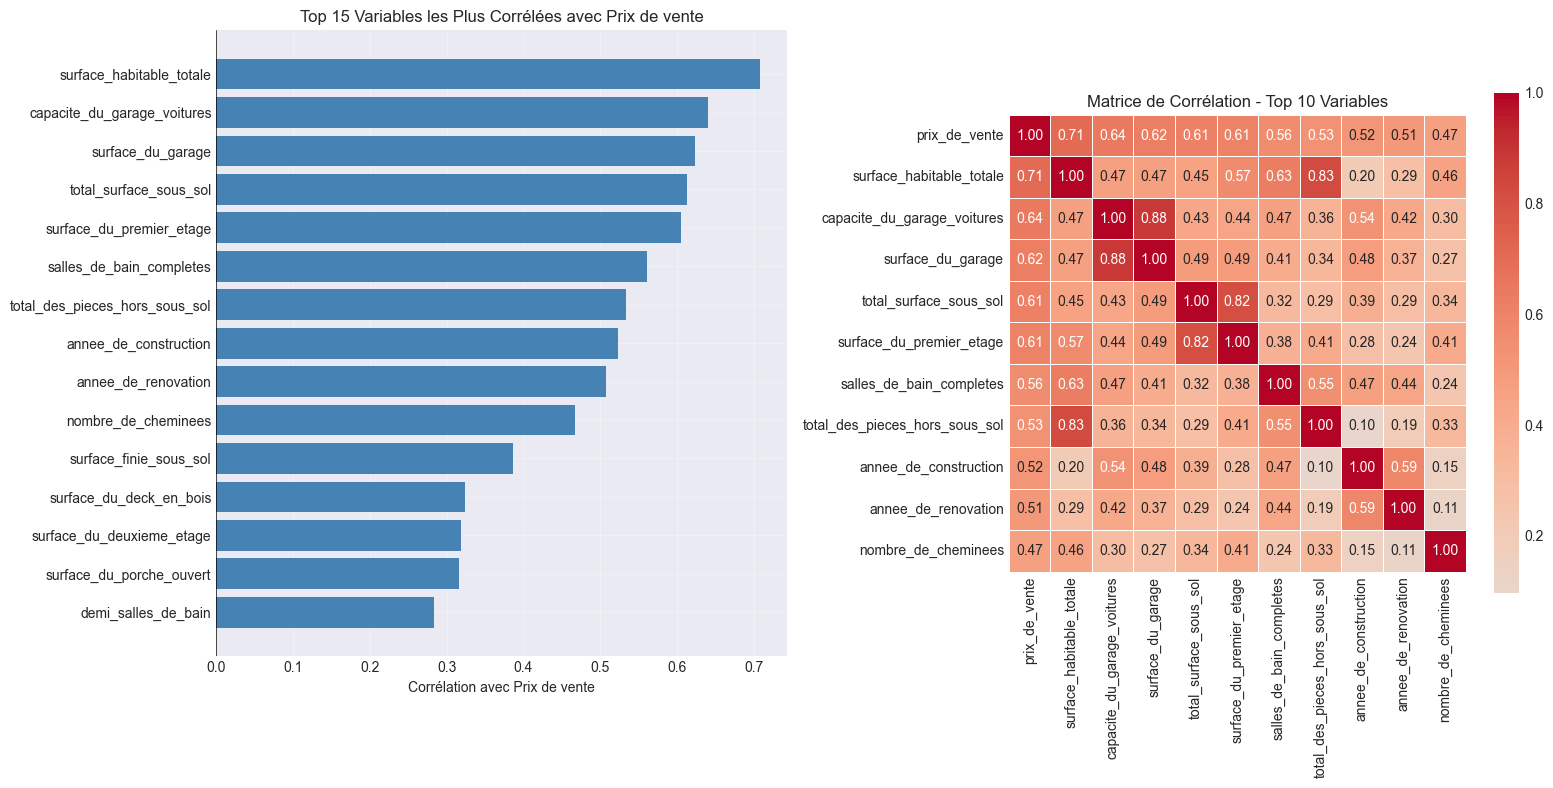


Observations:
   - Variable la plus corrélée: surface_habitable_totale (0.709)
   - 9 variables ont une corrélation forte (|r| > 0.5) avec Prix de vente
   - 14 variables ont une corrélation modérée (|r| > 0.3) avec Prix de vente


In [16]:
# Corrélations avec Prix de vente
print("=" * 60)
print("CORRÉLATIONS AVEC SALEPRICE")
print("=" * 60)

# Calculer les corrélations
correlations = train_df[numeric_cols].corr()['prix_de_vente'].sort_values(ascending=False)

print("\nTop 20 variables les plus correlees avec Prix de vente:\n")
top_corr = correlations.head(20)
for var, corr in top_corr.items():
    if var != 'prix_de_vente':
        print(f"   {var:20s}: {corr:6.3f} {'(forte)' if abs(corr) > 0.5 else '(moderee)' if abs(corr) > 0.3 else '(faible)'}")

print("\nBottom 10 variables les moins correlees avec Prix de vente:\n")
bottom_corr = correlations.tail(11)  # 11 car Prix de vente est inclus
for var, corr in bottom_corr.items():
    if var != 'prix_de_vente':
        print(f"   {var:20s}: {corr:6.3f}")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Top corrélations
top_15 = correlations.head(16).drop('prix_de_vente')  # Exclure Prix de vente
axes[0].barh(range(len(top_15)), top_15.values, color='steelblue')
axes[0].set_yticks(range(len(top_15)))
axes[0].set_yticklabels(top_15.index)
axes[0].set_xlabel('Corrélation avec Prix de vente')
axes[0].set_title('Top 15 Variables les Plus Corrélées avec Prix de vente')
axes[0].invert_yaxis()
axes[0].grid(True, alpha=0.3)
axes[0].axvline(x=0, color='black', linestyle='-', linewidth=0.5)

# Matrice de corrélation des top variables
top_corr_vars = correlations.head(11).index.tolist()  # Top 10 + Prix de vente
corr_matrix = train_df[top_corr_vars].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=axes[1])
axes[1].set_title('Matrice de Corrélation - Top 10 Variables')

plt.tight_layout()
plt.savefig('../output/figures/correlations_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nObservations:")
print(f"   - Variable la plus corrélée: {correlations.drop('prix_de_vente').index[0]} ({correlations.drop('prix_de_vente').iloc[0]:.3f})")
print(f"   - {len(correlations[abs(correlations) > 0.5]) - 1} variables ont une corrélation forte (|r| > 0.5) avec Prix de vente")
print(f"   - {len(correlations[abs(correlations) > 0.3]) - 1} variables ont une corrélation modérée (|r| > 0.3) avec Prix de vente")


## 9. Détection des Outliers


In [17]:
# ============================================================================
# DÉTECTION DES OUTLIERS
# ============================================================================
print("=" * 60)
print("DÉTECTION DES OUTLIERS")
print("=" * 60)

# ============================================================================
# TECHNIQUES D'IDENTIFICATION DES OUTLIERS
# ============================================================================
# 1. Méthode IQR (Interquartile Range) : 
#    - Calcule Q1 (25e percentile) et Q3 (75e percentile)
#    - IQR = Q3 - Q1
#    - Outliers : valeurs < Q1 - 1.5*IQR ou > Q3 + 1.5*IQR
#    - Technique robuste aux valeurs extrêmes
#
# 2. Méthode Z-Score :
#    - Calcule l'écart-type et la moyenne
#    - Z-score = (valeur - moyenne) / écart-type
#    - Outliers : |Z-score| > 3 (valeurs à plus de 3 écarts-types de la moyenne)
#    - Technique sensible aux valeurs extrêmes
# ============================================================================

def detect_outliers_iqr(df, column):
    """
    Détecte les outliers en utilisant la méthode IQR (Interquartile Range).
    Technique : Q1 - 1.5*IQR et Q3 + 1.5*IQR
    """
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

def detect_outliers_zscore(df, column, threshold=3):
    """
    Détecte les outliers en utilisant la méthode Z-Score.
    Technique : |Z-score| > threshold (par défaut 3)
    """
    mean = df[column].mean()
    std = df[column].std()
    if std == 0:  # Éviter la division par zéro
        return pd.DataFrame(), mean, std
    z_scores = np.abs((df[column] - mean) / std)
    outliers = df[z_scores > threshold]
    return outliers, mean, std

print("Fonctions de détection d'outliers définies avec succès!")


DÉTECTION DES OUTLIERS
Fonctions de détection d'outliers définies avec succès!


In [18]:
# ============================================================================
# PRÉPARATION DES DONNÉES ET DÉTECTION
# ============================================================================

# Analyser TOUTES les colonnes numériques (pas seulement les 4 clés)
numeric_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()
# Exclure l'identifiant qui n'a pas de sens pour la détection d'outliers
numeric_cols = [col for col in numeric_cols if col != 'identifiant']

print(f"\nAnalyse de {len(numeric_cols)} colonnes numériques...")
print("Techniques utilisées : IQR (Interquartile Range) et Z-Score (|Z| > 3)\n")

# Détection avec IQR et Z-Score - UNIQUEMENT les colonnes avec outliers
outliers_summary_iqr = []
outliers_summary_zscore = []

for var in numeric_cols:
    if var in train_df.columns:
        # Méthode IQR
        outliers_iqr, lower, upper = detect_outliers_iqr(train_df, var)
        if len(outliers_iqr) > 0:  # Seulement si des outliers sont détectés
            pct_iqr = (len(outliers_iqr) / len(train_df)) * 100
            outliers_summary_iqr.append({
                'Variable': var,
                'Méthode': 'IQR',
                'Outliers': len(outliers_iqr),
                'Pourcentage': f'{pct_iqr:.2f}%',
                'Limite Inf': f'{lower:.2f}',
                'Limite Sup': f'{upper:.2f}'
            })
        
        # Méthode Z-Score
        outliers_zscore, mean, std = detect_outliers_zscore(train_df, var, threshold=3)
        if len(outliers_zscore) > 0:  # Seulement si des outliers sont détectés
            pct_zscore = (len(outliers_zscore) / len(train_df)) * 100
            outliers_summary_zscore.append({
                'Variable': var,
                'Méthode': 'Z-Score',
                'Outliers': len(outliers_zscore),
                'Pourcentage': f'{pct_zscore:.2f}%',
                'Moyenne': f'{mean:.2f}',
                'Écart-type': f'{std:.2f}'
            })

print(f"Détection terminée : {len(outliers_summary_iqr)} colonnes avec outliers (IQR), {len(outliers_summary_zscore)} colonnes avec outliers (Z-Score)")



Analyse de 30 colonnes numériques...
Techniques utilisées : IQR (Interquartile Range) et Z-Score (|Z| > 3)

Détection terminée : 26 colonnes avec outliers (IQR), 26 colonnes avec outliers (Z-Score)


In [19]:
# ============================================================================
# RÉSULTATS : OUTLIERS DÉTECTÉS PAR MÉTHODE IQR
# ============================================================================

print("=" * 60)
print("COLONNES AVEC OUTLIERS DÉTECTÉS (Méthode IQR)")
print("=" * 60)

if outliers_summary_iqr:
    outliers_df_iqr = pd.DataFrame(outliers_summary_iqr)
    print(f"\n{len(outliers_summary_iqr)} colonnes avec outliers détectés par IQR:\n")
    print(outliers_df_iqr.to_string(index=False))
else:
    print("\nAucune colonne avec outliers détectés par la méthode IQR.")


COLONNES AVEC OUTLIERS DÉTECTÉS (Méthode IQR)

26 colonnes avec outliers détectés par IQR:

                                   Variable Méthode  Outliers Pourcentage Limite Inf Limite Sup
                    superficie_du_lot_pieds     IQR        69       4.73%    1481.50   17673.50
                      annee_de_construction     IQR         7       0.48%    1885.00    2069.00
                     surface_finie_sous_sol     IQR         7       0.48%   -1068.38    1780.62
                   surface_finie_sous_sol_2     IQR       167      11.44%       0.00       0.00
                 surface_non_finie_sous_sol     IQR        29       1.99%    -654.50    1685.50
                     total_surface_sous_sol     IQR        61       4.18%      42.00    2052.00
                   surface_du_premier_etage     IQR        20       1.37%     118.12    2155.12
                  surface_du_deuxieme_etage     IQR         2       0.14%   -1092.00    1820.00
          surface_finie_basse_qualite_pieds 

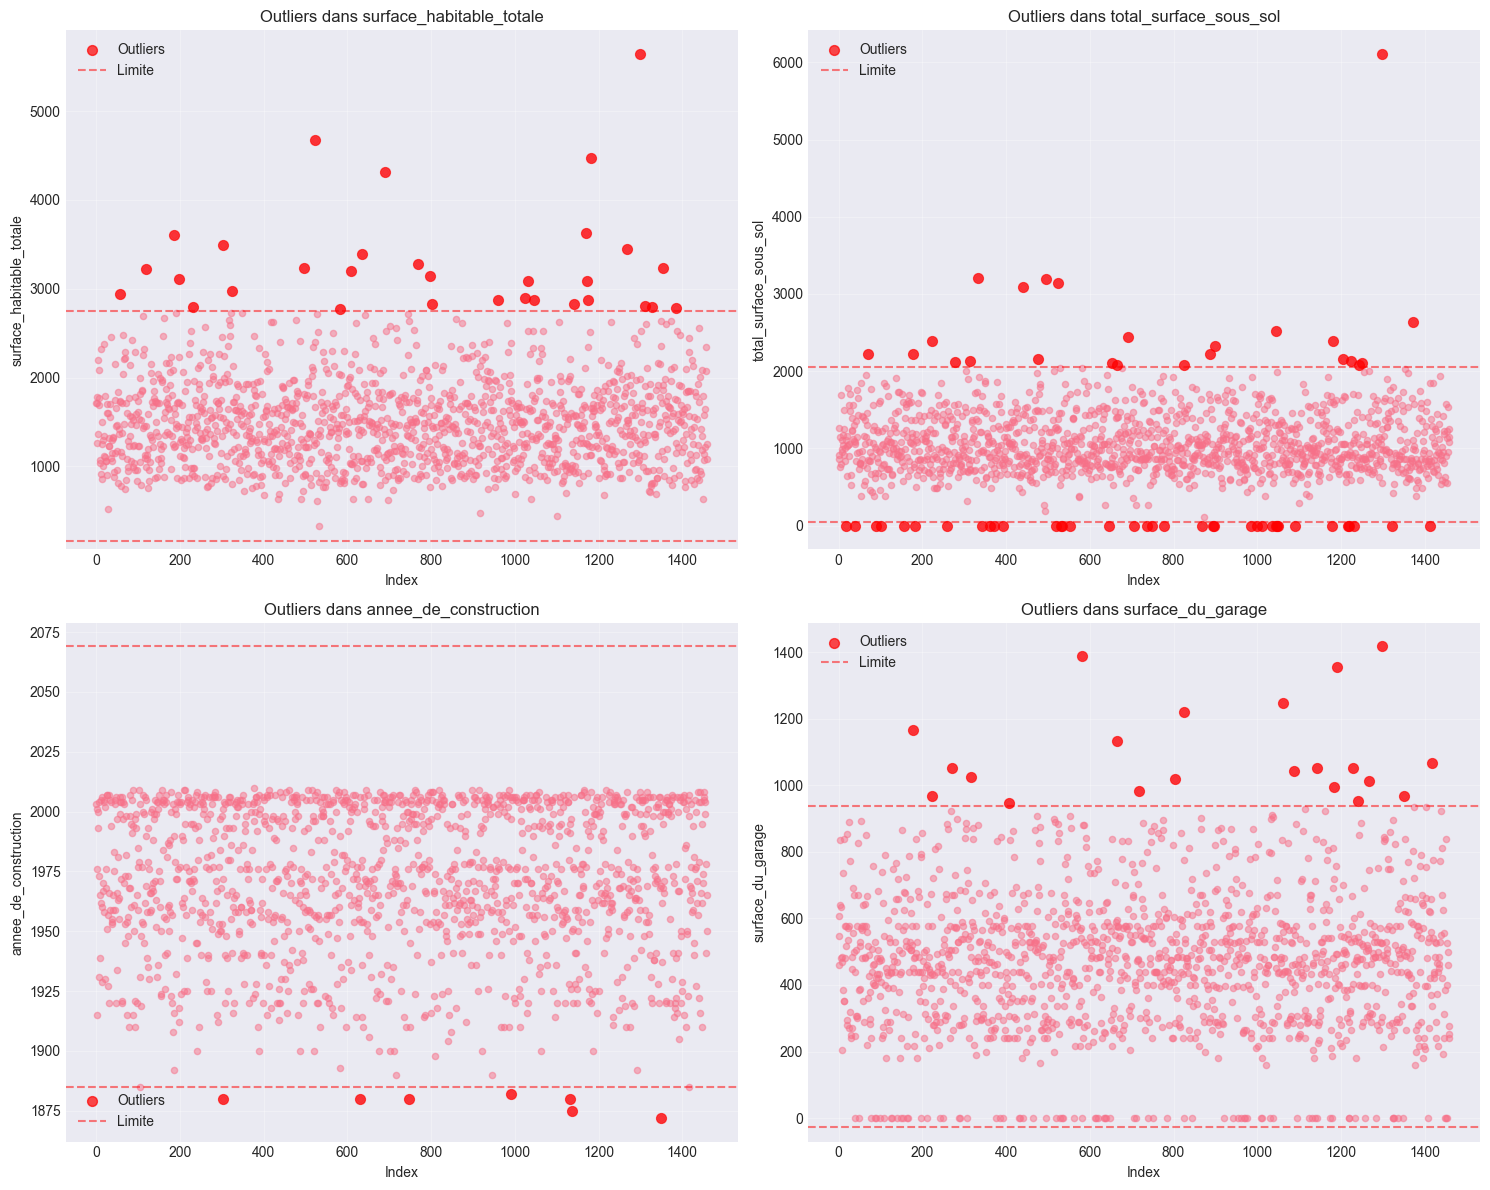


Analyse spécifique: GrLivArea vs Prix de vente
   Maisons avec GrLivArea > 4000 et Prix de vente < 300000: 2


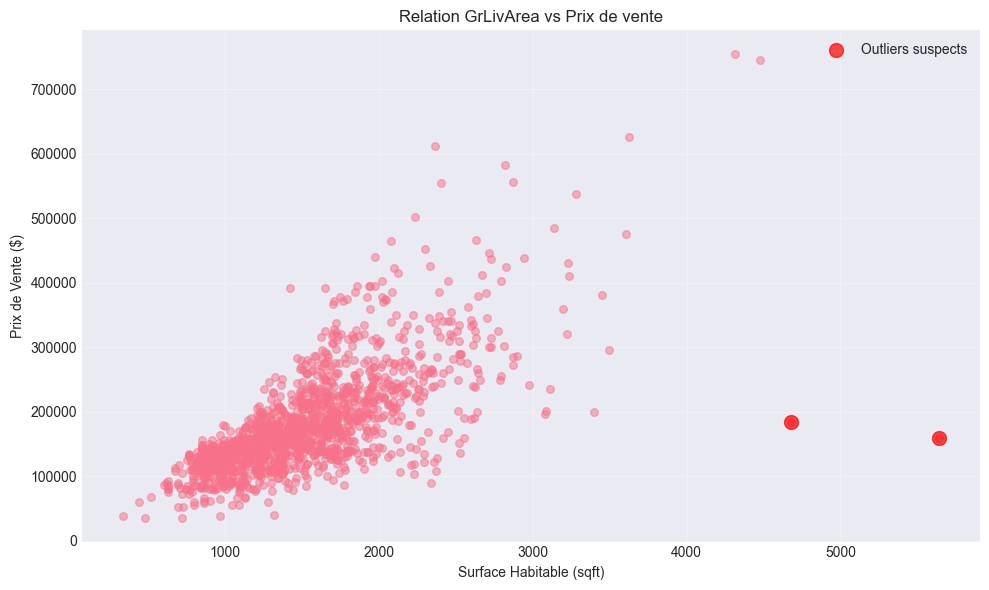

In [20]:
# ============================================================================
# VISUALISATION DES OUTLIERS
# ============================================================================

# Variables clés pour la visualisation
key_vars_for_outliers = [
    'surface_habitable_totale', 'total_surface_sous_sol', 
    'annee_de_construction', 'surface_du_garage'
]
key_vars_for_outliers = [v for v in key_vars_for_outliers if v in train_df.columns]

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

for idx, var in enumerate(key_vars_for_outliers):
    if var in train_df.columns:
        row = idx // 2
        col = idx % 2
        
        # Scatter plot avec outliers
        axes[row, col].scatter(train_df.index, train_df[var], alpha=0.5, s=20)
        
        # Identifier et marquer les outliers
        outliers, lower, upper = detect_outliers_iqr(train_df, var)
        if len(outliers) > 0:
            axes[row, col].scatter(outliers.index, outliers[var], 
                                  color='red', s=50, alpha=0.7, label='Outliers')
            axes[row, col].axhline(y=upper, color='r', linestyle='--', alpha=0.5, label='Limite')
            axes[row, col].axhline(y=lower, color='r', linestyle='--', alpha=0.5)
        
        axes[row, col].set_xlabel('Index')
        axes[row, col].set_ylabel(var)
        axes[row, col].set_title(f'Outliers dans {var}')
        axes[row, col].legend()
        axes[row, col].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../output/figures/outliers_detection.png', dpi=300, bbox_inches='tight')
plt.show()

# Outliers spécifiques pour GrLivArea vs Prix de vente
if 'surface_habitable_totale' in train_df.columns and 'prix_de_vente' in train_df.columns:
    print("\nAnalyse spécifique: GrLivArea vs Prix de vente")
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.scatter(train_df['surface_habitable_totale'], train_df['prix_de_vente'], alpha=0.5, s=30)
    
    # Identifier les outliers (grande surface mais prix bas)
    outliers_grliv = train_df[(train_df['surface_habitable_totale'] > 4000) & (train_df['prix_de_vente'] < 300000)]
    if len(outliers_grliv) > 0:
        ax.scatter(outliers_grliv['surface_habitable_totale'], outliers_grliv['prix_de_vente'], 
                  color='red', s=100, alpha=0.7, label='Outliers suspects')
        print(f"   Maisons avec GrLivArea > 4000 et Prix de vente < 300000: {len(outliers_grliv)}")
    
    ax.set_xlabel('Surface Habitable (sqft)')
    ax.set_ylabel('Prix de Vente ($)')
    ax.set_title('Relation GrLivArea vs Prix de vente')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('../output/figures/grlivarea_vs_saleprice.png', dpi=300, bbox_inches='tight')
    plt.show()


## 10. Relations entre Variables Clés et Prix


RELATIONS VARIABLES CLÉS vs PRIX


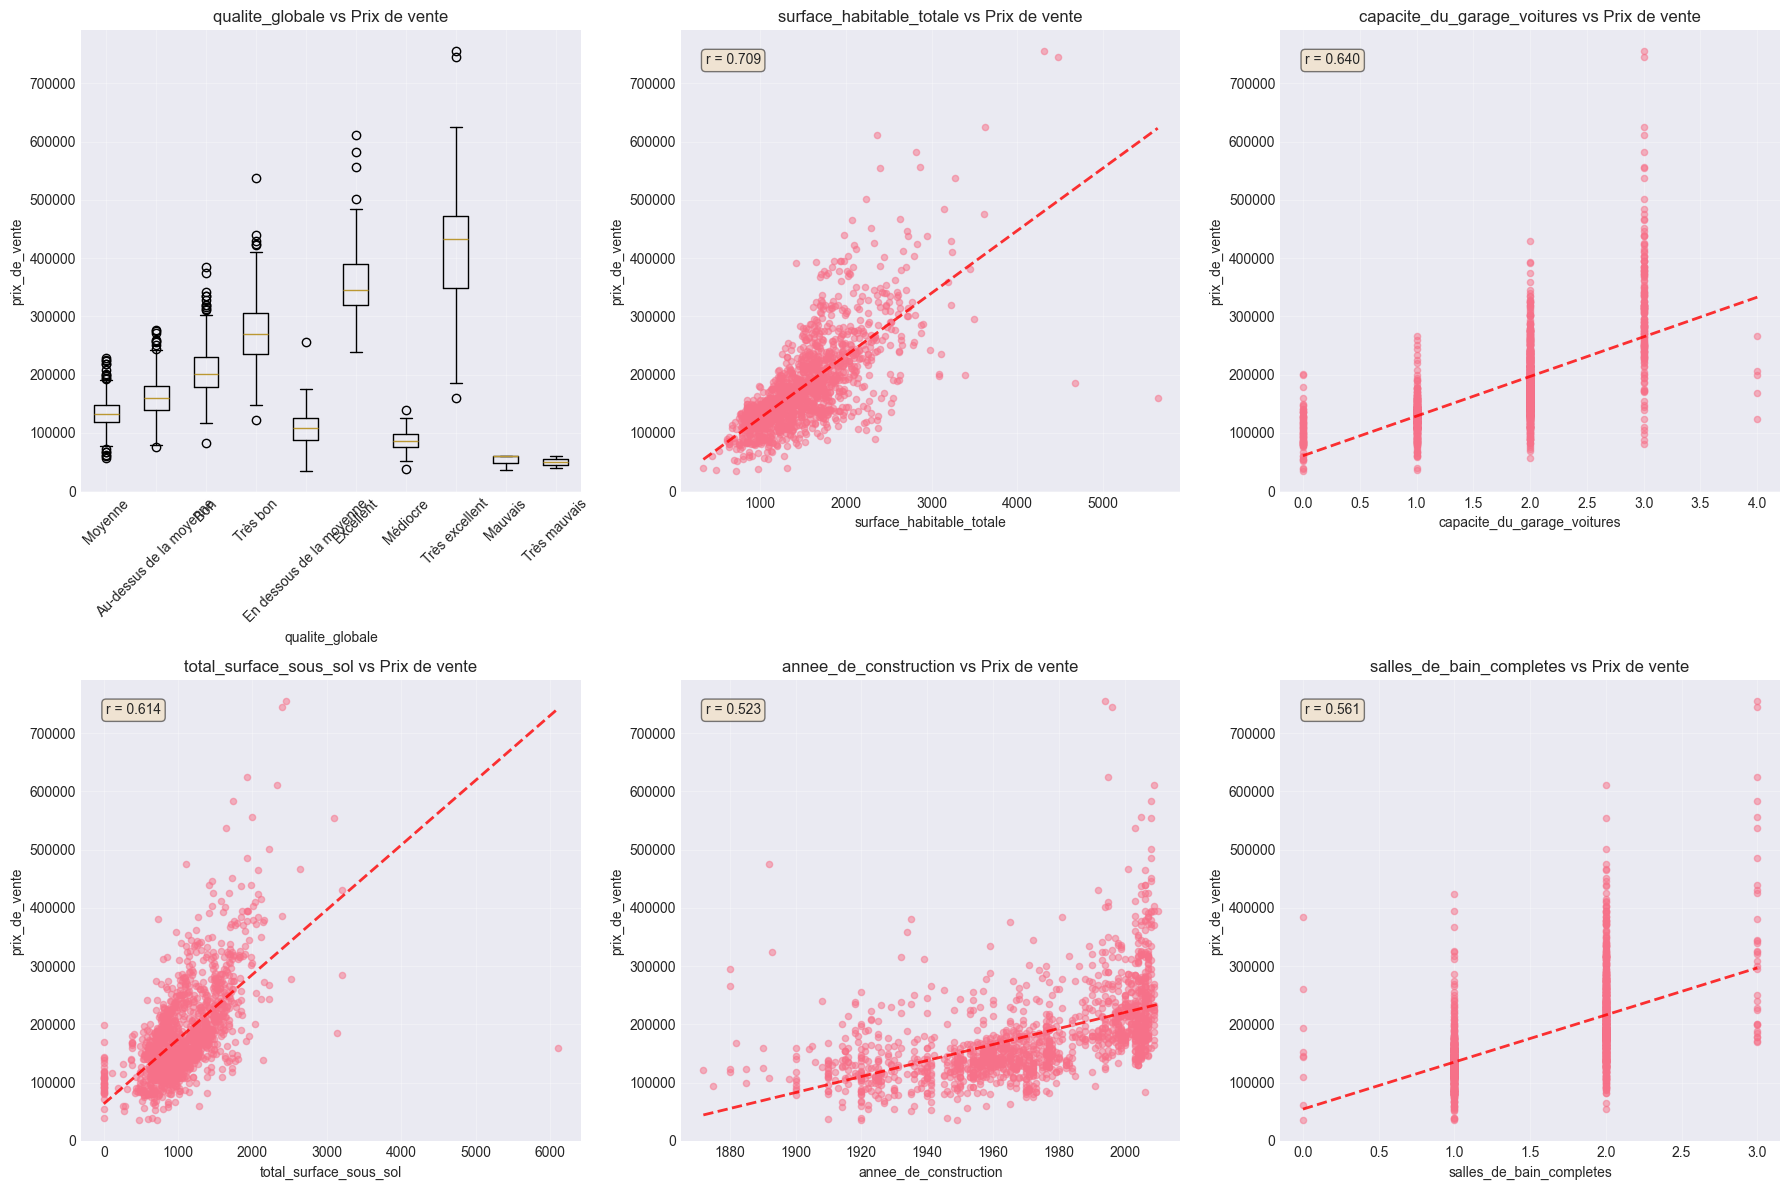

In [21]:
# Analyse des relations entre variables clés et prix
print("=" * 60)
print("RELATIONS VARIABLES CLÉS vs PRIX")
print("=" * 60)

# Variables à analyser
key_analysis_vars = ['qualite_globale', 'surface_habitable_totale', 'capacite_du_garage_voitures', 'total_surface_sous_sol', 
                     'annee_de_construction', 'salles_de_bain_completes']

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, var in enumerate(key_analysis_vars):
    if var in train_df.columns:
        if train_df[var].dtype in ['int64', 'float64']:
            # Scatter plot pour variables numériques
            axes[idx].scatter(train_df[var], train_df['prix_de_vente'], alpha=0.5, s=20)
            axes[idx].set_xlabel(var)
            axes[idx].set_ylabel('prix_de_vente')
            axes[idx].set_title(f'{var} vs Prix de vente')
            
            # Ajouter une ligne de tendance
            z = np.polyfit(train_df[var].dropna(), train_df.loc[train_df[var].notna(), 'prix_de_vente'], 1)
            p = np.poly1d(z)
            x_line = np.linspace(train_df[var].min(), train_df[var].max(), 100)
            axes[idx].plot(x_line, p(x_line), "r--", alpha=0.8, linewidth=2)
            
            # Calculer la corrélation
            corr = train_df[[var, 'prix_de_vente']].corr().iloc[0, 1]
            axes[idx].text(0.05, 0.95, f'r = {corr:.3f}', transform=axes[idx].transAxes,
                          verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        else:
            # Box plot pour variables catégorielles
            categories = train_df[var].value_counts().head(10).index
            data_to_plot = [train_df[train_df[var] == cat]['prix_de_vente'].values for cat in categories]
            axes[idx].boxplot(data_to_plot, labels=categories)
            axes[idx].set_xlabel(var)
            axes[idx].set_ylabel('prix_de_vente')
            axes[idx].set_title(f'{var} vs Prix de vente')
            axes[idx].tick_params(axis='x', rotation=45)
        
        axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../output/figures/key_vars_vs_price.png', dpi=300, bbox_inches='tight')
plt.show()


## 12. Traitement des Valeurs Aberrantes (Outliers)


In [22]:
# Traitement des valeurs aberrantes
print("=" * 60)
print("TRAITEMENT DES VALEURS ABERRANTES")
print("=" * 60)

# Copie des données pour le traitement
train_processed = train_df.copy()

# Fonction pour détecter et traiter les outliers Type 1: GrLivArea > 4000 et Prix de vente < 300000
def treat_outliers_type1(df):
    """Traiter les outliers Type 1: grande surface mais prix bas."""
    outliers = df[(df['surface_habitable_totale'] > 4000) & (df['prix_de_vente'] < 300000)].copy()
    
    if len(outliers) == 0:
        print("Aucun outlier Type 1 détecté.")
        return df
    
    print(f"\nType 1: GrLivArea > 4000 et Prix de vente < 300000")
    print(f"Nombre d'outliers détectés: {len(outliers)}")
    
    for idx in outliers.index:
        # Trouver des maisons similaires
        neighborhood = df.loc[idx, 'quartier']
        overall_qual = df.loc[idx, 'qualite_globale']
        grlivarea = df.loc[idx, 'surface_habitable_totale']
        
        # Convertir la qualité globale en nombre si c'est une chaîne
        qualite_mapping_inverse = {
            "Très excellent": 10, "Excellent": 9, "Très bon": 8, "Bon": 7,
            "Au-dessus de la moyenne": 6, "Moyenne": 5, "En dessous de la moyenne": 4,
            "Médiocre": 3, "Mauvais": 2, "Très mauvais": 1
        }
        if isinstance(overall_qual, str):
            overall_qual_num = qualite_mapping_inverse.get(overall_qual, 5)  # Default à 5 si non trouvé
        else:
            overall_qual_num = overall_qual
        
        # Maisons similaires: même quartier, qualité similaire (±1), surface proche (±20%)
        # Convertir qualite_globale en nombres pour la comparaison
        df_qualite_num = df['qualite_globale'].apply(
            lambda x: qualite_mapping_inverse.get(x, 5) if isinstance(x, str) else x
        )
        similar = df[
            (df['quartier'] == neighborhood) &
            (df_qualite_num >= overall_qual_num - 1) &
            (df_qualite_num <= overall_qual_num + 1) &
            (df['surface_habitable_totale'] >= grlivarea * 0.8) &
            (df['surface_habitable_totale'] <= grlivarea * 1.2) &
            (df.index != idx)
        ]
        
        if len(similar) > 5:
            # Calculer la régression log-linéaire
            log_price = np.log1p(similar['prix_de_vente'])
            log_area = np.log1p(similar['surface_habitable_totale'])
            
            # Régression simple
            slope = np.cov(log_price, log_area)[0, 1] / np.var(log_area)
            intercept = log_price.mean() - slope * log_area.mean()
            
            # Ajuster le prix
            log_area_outlier = np.log1p(grlivarea)
            log_price_adjusted = intercept + slope * log_area_outlier
            price_adjusted = np.expm1(log_price_adjusted)
            
            # Limiter au percentile 99 pour sécurité
            p99_price = df['prix_de_vente'].quantile(0.99)
            price_adjusted = min(price_adjusted, p99_price)
            
            old_price = df.loc[idx, 'prix_de_vente']
            df.loc[idx, 'prix_de_vente'] = price_adjusted
            
            print(f"  Index {idx}: Prix ajusté de ${old_price:,.0f} à ${price_adjusted:,.0f}")
        else:
            # Fallback: capping au percentile 99
            p99_price = df['prix_de_vente'].quantile(0.99)
            old_price = df.loc[idx, 'prix_de_vente']
            df.loc[idx, 'prix_de_vente'] = min(old_price * 1.2, p99_price)
            print(f"  Index {idx}: Prix ajusté (fallback) de ${old_price:,.0f} à ${df.loc[idx, 'prix_de_vente']:,.0f}")
    
    return df

# Fonction pour traiter les outliers Type 2: TotalBsmtSF >= 3000
def treat_outliers_type2(df):
    """Traiter les outliers Type 2: sous-sol très grand."""
    # Convertir en numérique si nécessaire
    if 'total_surface_sous_sol' in df.columns:
        df['total_surface_sous_sol'] = pd.to_numeric(df['total_surface_sous_sol'], errors='coerce')
    outliers = df[df['total_surface_sous_sol'] >= 3000].copy()
    
    if len(outliers) == 0:
        print("\nAucun outlier Type 2 détecté.")
        return df
    
    print(f"\nType 2: TotalBsmtSF >= 3000")
    print(f"Nombre d'outliers détectés: {len(outliers)}")
    
    p99_bsmt = df['total_surface_sous_sol'].quantile(0.99)
    
    for idx in outliers.index:
        total_bsmt = pd.to_numeric(df.loc[idx, 'total_surface_sous_sol'], errors='coerce')
        grlivarea = df.loc[idx, 'surface_habitable_totale']
        
        # Vérifier la cohérence avec GrLivArea
        ratio = total_bsmt / grlivarea if grlivarea > 0 else 0
        
        if ratio > 1.5:  # Incohérent
            new_value = min(p99_bsmt, grlivarea * 1.2)
        else:  # Cohérent mais extrême
            new_value = p99_bsmt
        
        old_value = df.loc[idx, 'total_surface_sous_sol']
        df.loc[idx, 'total_surface_sous_sol'] = new_value
        print(f"  Index {idx}: TotalBsmtSF ajusté de {old_value:.0f} à {new_value:.0f}")
    
    return df

# Appliquer les traitements sur les données d'entraînement
print(f"\n{'='*60}")
print("TRAITEMENT DES DONNÉES D'ENTRAÎNEMENT")
print(f"{'='*60}")
print(f"Observations avant traitement: {len(train_processed)}")
train_processed = treat_outliers_type1(train_processed)
train_processed = treat_outliers_type2(train_processed)
print(f"Observations après traitement: {len(train_processed)}")
print("Aucune observation supprimée - transformation contextuelle appliquée.")

# Traitement des données de test
print(f"\n{'='*60}")
print("TRAITEMENT DES DONNÉES DE TEST")
print(f"{'='*60}")

# Copie des données de test pour le traitement
test_processed = test_df.copy()

# Note: Pour les données de test, on ne peut traiter que les outliers Type 2
# car il n'y a pas de variable Prix de vente dans le test set
print(f"Observations avant traitement: {len(test_processed)}")

# Traiter les outliers Type 2 pour les données de test
# Utiliser les percentiles du train pour la cohérence
# Convertir en numérique si nécessaire
if 'total_surface_sous_sol' in train_processed.columns:
    train_processed['total_surface_sous_sol'] = pd.to_numeric(train_processed['total_surface_sous_sol'], errors='coerce')
if 'total_surface_sous_sol' in test_processed.columns:
    test_processed['total_surface_sous_sol'] = pd.to_numeric(test_processed['total_surface_sous_sol'], errors='coerce')

p99_bsmt_train = train_processed['total_surface_sous_sol'].quantile(0.99) if 'total_surface_sous_sol' in train_processed.columns else 3000

if 'total_surface_sous_sol' in test_processed.columns:
    outliers_test = test_processed[test_processed['total_surface_sous_sol'] >= 3000].copy()
    
    if len(outliers_test) > 0:
        print(f"\nType 2: TotalBsmtSF >= 3000")
        print(f"Nombre d'outliers détectés dans le test: {len(outliers_test)}")
        
        for idx in outliers_test.index:
            total_bsmt = pd.to_numeric(test_processed.loc[idx, 'total_surface_sous_sol'], errors='coerce')
            grlivarea = test_processed.loc[idx, 'surface_habitable_totale'] if 'surface_habitable_totale' in test_processed.columns else 0
            
            # Vérifier la cohérence avec GrLivArea
            ratio = total_bsmt / grlivarea if grlivarea > 0 else 0
            
            if ratio > 1.5:  # Incohérent
                new_value = min(p99_bsmt_train, grlivarea * 1.2)
            else:  # Cohérent mais extrême
                new_value = p99_bsmt_train
            
            old_value = test_processed.loc[idx, 'total_surface_sous_sol']
            test_processed.loc[idx, 'total_surface_sous_sol'] = new_value
            print(f"  Index {idx}: TotalBsmtSF ajusté de {old_value:.0f} à {new_value:.0f}")
    else:
        print("\nAucun outlier Type 2 détecté dans les données de test.")
else:
    print("\nColonne TotalBsmtSF absente des données de test.")

print(f"Observations après traitement: {len(test_processed)}")
print("Aucune observation supprimée - transformation contextuelle appliquée.")

# Sauvegarder les données traitées
print(f"\n{'='*60}")
print("SAUVEGARDE DES DONNÉES TRAITÉES")
print(f"{'='*60}")

output_dir = Path("../data/processed")
output_dir.mkdir(parents=True, exist_ok=True)

train_outliers_path = output_dir / "train_outliers_treated.csv"
test_outliers_path = output_dir / "test_outliers_treated.csv"

train_processed.to_csv(train_outliers_path, index=False)
test_processed.to_csv(test_outliers_path, index=False)

print(f"\nDonnées sauvegardées:")
print(f"   - Train: {train_outliers_path}")
print(f"   - Test: {test_outliers_path}")
print(f"\nForme des données:")
print(f"   - Train: {train_processed.shape}")
print(f"   - Test: {test_processed.shape}")


TRAITEMENT DES VALEURS ABERRANTES

TRAITEMENT DES DONNÉES D'ENTRAÎNEMENT
Observations avant traitement: 1460

Type 1: GrLivArea > 4000 et Prix de vente < 300000
Nombre d'outliers détectés: 2
  Index 523: Prix ajusté (fallback) de $184,750 à $221,700
  Index 1298: Prix ajusté (fallback) de $160,000 à $192,000

Type 2: TotalBsmtSF >= 3000
Nombre d'outliers détectés: 5
  Index 332: TotalBsmtSF ajusté de 3206 à 1955
  Index 440: TotalBsmtSF ajusté de 3094 à 2155
  Index 496: TotalBsmtSF ajusté de 3200 à 2155
  Index 523: TotalBsmtSF ajusté de 3138 à 2155
  Index 1298: TotalBsmtSF ajusté de 6110 à 2155
Observations après traitement: 1460
Aucune observation supprimée - transformation contextuelle appliquée.

TRAITEMENT DES DONNÉES DE TEST
Observations avant traitement: 1459

Type 2: TotalBsmtSF >= 3000
Nombre d'outliers détectés dans le test: 1
  Index 1089: TotalBsmtSF ajusté de 5095 à 2143
Observations après traitement: 1459
Aucune observation supprimée - transformation contextuelle appliq

## 13. Transformation de la Variable Cible (Prix de vente)


TRANSFORMATION DE LA VARIABLE CIBLE (Prix de vente)

Avant transformation:
   Skewness: 1.881
   Kurtosis: 6.529
   Moyenne: $180,968.42
   Médiane: $163,000.00

Après transformation log1p:
   Skewness: 0.120
   Kurtosis: 0.806
   Moyenne: 12.024
   Médiane: 12.002


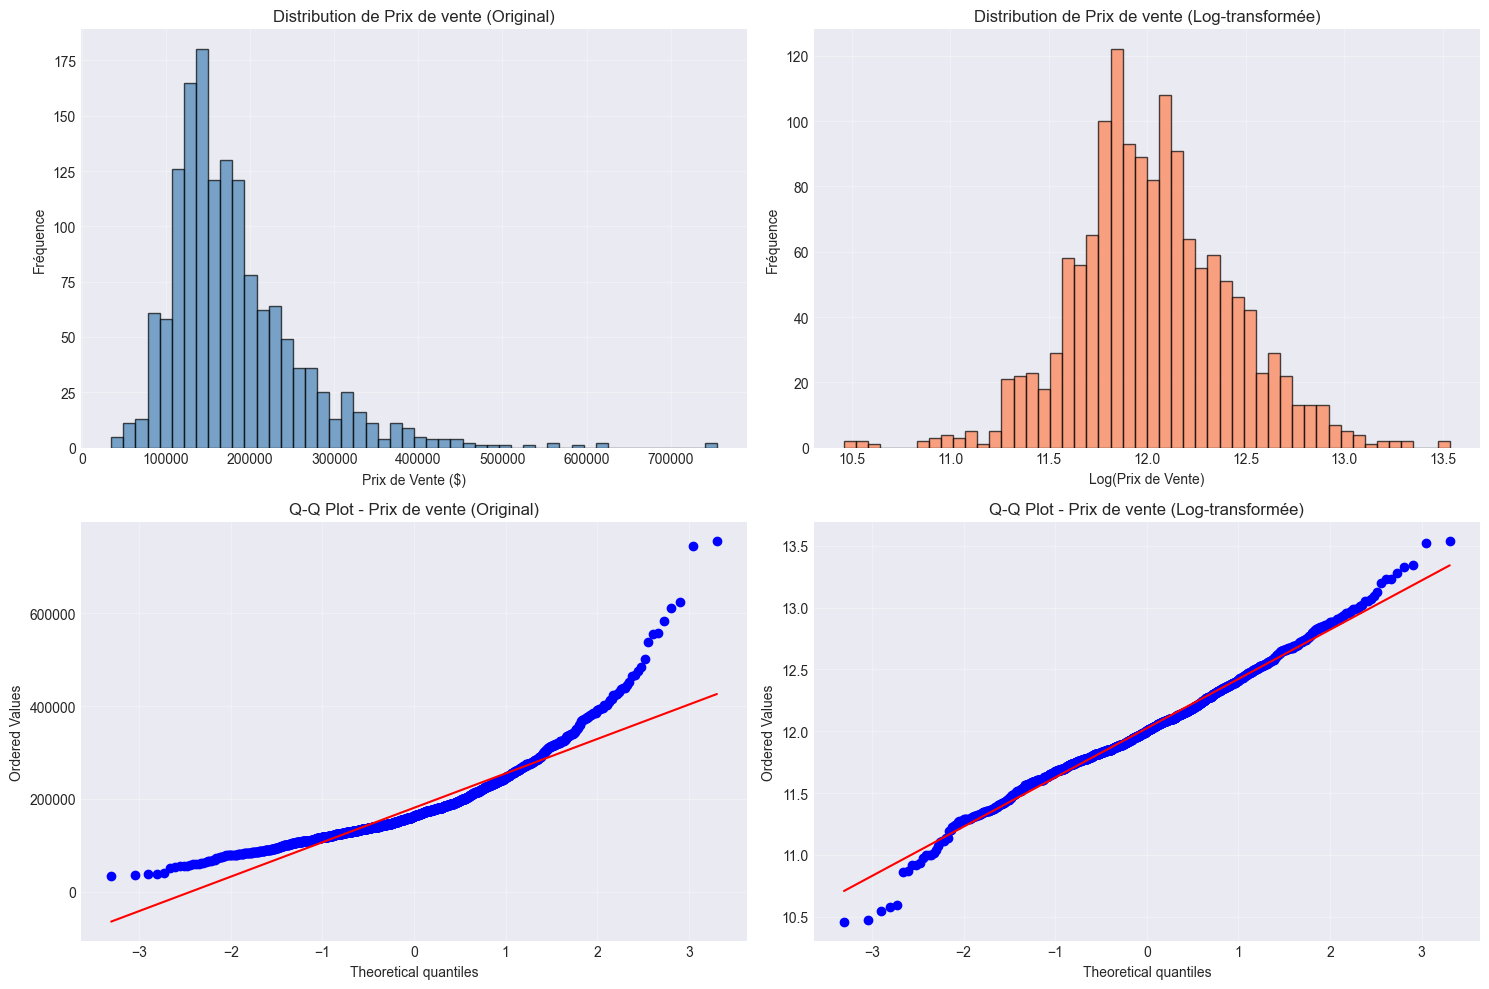


Observation: La transformation log1p normalise significativement la distribution.
La variable Prix de vente_log sera utilisée pour l'entraînement du modèle.


In [23]:
# Transformation logarithmique de la variable cible
print("=" * 60)
print("TRANSFORMATION DE LA VARIABLE CIBLE (Prix de vente)")
print("=" * 60)

# Analyser la distribution avant transformation
print("\nAvant transformation:")
print(f"   Skewness: {train_processed['prix_de_vente'].skew():.3f}")
print(f"   Kurtosis: {train_processed['prix_de_vente'].kurtosis():.3f}")
print(f"   Moyenne: ${train_processed['prix_de_vente'].mean():,.2f}")
print(f"   Médiane: ${train_processed['prix_de_vente'].median():,.2f}")

# Créer une copie pour la transformation
train_final = train_processed.copy()

# Appliquer la transformation logarithmique (log1p pour gérer les valeurs > 0)
train_final['prix_de_vente_log'] = np.log1p(train_final['prix_de_vente'])

# Analyser la distribution après transformation
print("\nAprès transformation log1p:")
print(f"   Skewness: {train_final['prix_de_vente_log'].skew():.3f}")
print(f"   Kurtosis: {train_final['prix_de_vente_log'].kurtosis():.3f}")
print(f"   Moyenne: {train_final['prix_de_vente_log'].mean():.3f}")
print(f"   Médiane: {train_final['prix_de_vente_log'].median():.3f}")

# Visualisation
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Distribution avant transformation
axes[0, 0].hist(train_processed['prix_de_vente'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 0].set_xlabel('Prix de Vente ($)')
axes[0, 0].set_ylabel('Fréquence')
axes[0, 0].set_title('Distribution de Prix de vente (Original)')
axes[0, 0].grid(True, alpha=0.3)

# Distribution après transformation
axes[0, 1].hist(train_final['prix_de_vente_log'], bins=50, edgecolor='black', alpha=0.7, color='coral')
axes[0, 1].set_xlabel('Log(Prix de Vente)')
axes[0, 1].set_ylabel('Fréquence')
axes[0, 1].set_title('Distribution de Prix de vente (Log-transformée)')
axes[0, 1].grid(True, alpha=0.3)

# Q-Q plot avant transformation
from scipy import stats
stats.probplot(train_processed['prix_de_vente'], dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot - Prix de vente (Original)')
axes[1, 0].grid(True, alpha=0.3)

# Q-Q plot après transformation
stats.probplot(train_final['prix_de_vente_log'], dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot - Prix de vente (Log-transformée)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../output/figures/saleprice_transformation.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nObservation: La transformation log1p normalise significativement la distribution.")
print("La variable Prix de vente_log sera utilisée pour l'entraînement du modèle.")


## 14. Analyse de Multicolinéarité


ANALYSE DE MULTICOLINÉARITÉ

Variables fortement corrélées avec Prix de vente (|r| > 0.5): 10
   prix_de_vente_log   :  0.948
   surface_habitable_totale:  0.713
   total_surface_sous_sol:  0.647
   capacite_du_garage_voitures:  0.641
   surface_du_garage   :  0.625
   surface_du_premier_etage:  0.610
   salles_de_bain_completes:  0.562
   total_des_pieces_hors_sous_sol:  0.535
   annee_de_construction:  0.524
   annee_de_renovation :  0.508

PAIRES DE VARIABLES FORTEMENT CORRÉLÉES ENTRE ELLES

4 paires avec corrélation > 0.7 (multicolinéarité potentielle):

   prix_de_vente_log    <-> surface_habitable_totale:  0.705
   surface_habitable_totale <-> total_des_pieces_hors_sous_sol:  0.825
   total_surface_sous_sol <-> surface_du_premier_etage:  0.795
   capacite_du_garage_voitures <-> surface_du_garage   :  0.882

RECOMMANDATIONS POUR LA MULTICOLINÉARITÉ

Pour chaque paire fortement corrélée:
   1. Conserver la variable la plus corrélée avec Prix de vente
   2. Supprimer ou combiner les

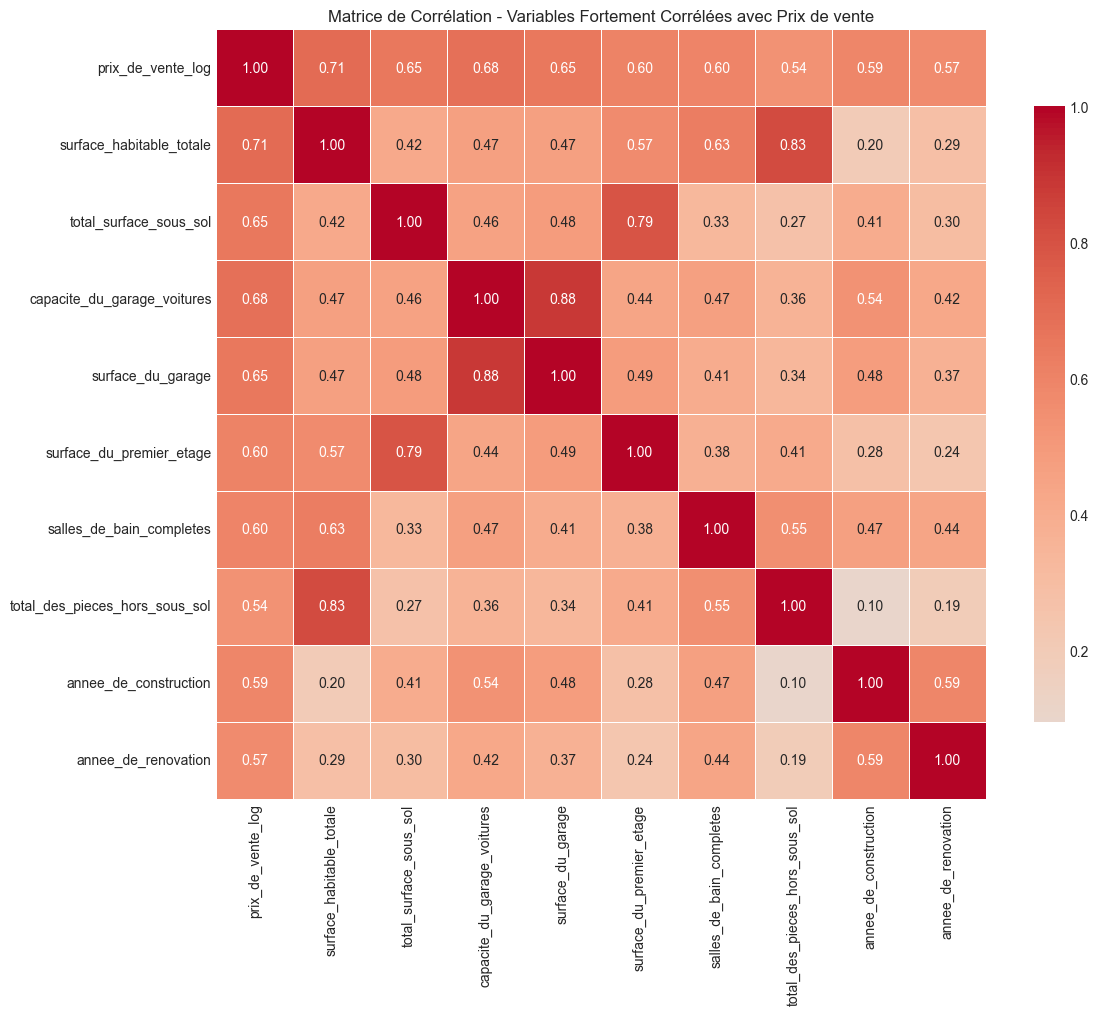

In [24]:
# Analyse de multicolinéarité entre variables fortement corrélées avec Prix de vente
print("=" * 60)
print("ANALYSE DE MULTICOLINÉARITÉ")
print("=" * 60)

# Identifier les variables numériques fortement corrélées avec Prix de vente
numeric_cols_final = train_final.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols_final = [col for col in numeric_cols_final if col not in ['identifiant', 'prix_de_vente', 'Prix de vente_log']]

# Calculer les corrélations avec Prix de vente
correlations_with_target = train_final[numeric_cols_final + ['prix_de_vente']].corr()['prix_de_vente'].sort_values(ascending=False)
correlations_with_target = correlations_with_target.drop('prix_de_vente')

# Sélectionner les variables fortement corrélées (|r| > 0.5)
strong_corr_vars = correlations_with_target[abs(correlations_with_target) > 0.5].index.tolist()

print(f"\nVariables fortement corrélées avec Prix de vente (|r| > 0.5): {len(strong_corr_vars)}")
for var in strong_corr_vars:
    print(f"   {var:20s}: {correlations_with_target[var]:6.3f}")

# Calculer la matrice de corrélation entre ces variables
if len(strong_corr_vars) > 1:
    corr_matrix_strong = train_final[strong_corr_vars].corr()
    
    # Identifier les paires de variables fortement corrélées entre elles
    print("\n" + "=" * 60)
    print("PAIRES DE VARIABLES FORTEMENT CORRÉLÉES ENTRE ELLES")
    print("=" * 60)
    
    high_corr_pairs = []
    for i in range(len(strong_corr_vars)):
        for j in range(i+1, len(strong_corr_vars)):
            var1 = strong_corr_vars[i]
            var2 = strong_corr_vars[j]
            corr_value = corr_matrix_strong.loc[var1, var2]
            
            if abs(corr_value) > 0.7:  # Seuil pour multicolinéarité
                high_corr_pairs.append({
                    'Variable 1': var1,
                    'Variable 2': var2,
                    'Corrélation': corr_value
                })
    
    if high_corr_pairs:
        print(f"\n{len(high_corr_pairs)} paires avec corrélation > 0.7 (multicolinéarité potentielle):\n")
        for pair in high_corr_pairs:
            print(f"   {pair['Variable 1']:20s} <-> {pair['Variable 2']:20s}: {pair['Corrélation']:6.3f}")
        
        # Recommandations
        print("\n" + "=" * 60)
        print("RECOMMANDATIONS POUR LA MULTICOLINÉARITÉ")
        print("=" * 60)
        print("\nPour chaque paire fortement corrélée:")
        print("   1. Conserver la variable la plus corrélée avec Prix de vente")
        print("   2. Supprimer ou combiner les variables redondantes")
        print("   3. Utiliser des techniques de réduction de dimensionnalité (PCA)")
        print("   4. Appliquer une régularisation (L1/L2) dans le modèle")
        
        # Créer un DataFrame avec les recommandations
        recommendations = []
        for pair in high_corr_pairs:
            var1_corr = abs(correlations_with_target[pair['Variable 1']])
            var2_corr = abs(correlations_with_target[pair['Variable 2']])
            
            if var1_corr > var2_corr:
                keep = pair['Variable 1']
                remove = pair['Variable 2']
            else:
                keep = pair['Variable 2']
                remove = pair['Variable 1']
            
            recommendations.append({
                'Variable à conserver': keep,
                'Variable à considérer pour suppression': remove,
                'Corrélation entre elles': pair['Corrélation']
            })
        
        recommendations_df = pd.DataFrame(recommendations)
        print("\n" + recommendations_df.to_string(index=False))
        
        # Visualisation de la matrice de corrélation
        fig, ax = plt.subplots(figsize=(12, 10))
        sns.heatmap(corr_matrix_strong, annot=True, fmt='.2f', cmap='coolwarm', 
                   center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
        ax.set_title('Matrice de Corrélation - Variables Fortement Corrélées avec Prix de vente')
        plt.tight_layout()
        plt.savefig('../output/figures/multicollinearity_analysis.png', dpi=300, bbox_inches='tight')
        plt.show()
    else:
        print("\nAucune paire de variables avec corrélation > 0.7 détectée.")
        print("Pas de problème de multicolinéarité majeur entre les variables fortement corrélées avec Prix de vente.")
else:
    print("\nMoins de 2 variables fortement corrélées - pas d'analyse de multicolinéarité nécessaire.")


## 14.5. Tests ANOVA pour les Variables Qualitatives

Les tests ANOVA (Analysis of Variance) permettent d'identifier les variables qualitatives qui ont un impact significatif sur le prix de vente. Un test ANOVA vérifie si les moyennes de Prix de vente diffèrent significativement entre les groupes définis par une variable catégorielle.

**Hypothèses du test ANOVA:**
- H0: Les moyennes de Prix de vente sont identiques pour tous les groupes
- H1: Au moins une moyenne diffère significativement

**Interprétation:**
- p-value < 0.05: La variable a un impact significatif sur le prix (rejet de H0)
- p-value >= 0.05: Pas d'impact significatif détecté

Variables qualitatives significatives (p < 0.05) doivent être intégrées dans le modèle.


TESTS ANOVA POUR LES VARIABLES QUALITATIVES

Nombre de variables qualitatives à tester: 50

RÉSULTATS DES TESTS ANOVA

Nombre total de variables testées: 49
Variables significatives (p < 0.05): 46
Variables très significatives (p < 0.01): 44

VARIABLES QUALITATIVES SIGNIFICATIVES (p < 0.05)

                        Variable  F-statistique       p-value  Taille effet (R²)
                 qualite_globale     355.219571  0.000000e+00           0.687969
                        quartier      71.535420 5.977218e-225           0.544712
              qualite_exterieure     448.215741 3.177619e-206           0.480120
             qualite_du_sous_sol     318.859607 4.532124e-197           0.467119
           qualite_de_la_cuisine     411.353390 1.696805e-193           0.458748
   finition_interieure_du_garage     214.716594 2.576731e-115           0.306716
          qualite_de_la_cheminee     121.448124 1.543610e-107           0.294600
 annee_de_construction_du_garage       9.607541  9.122523e-

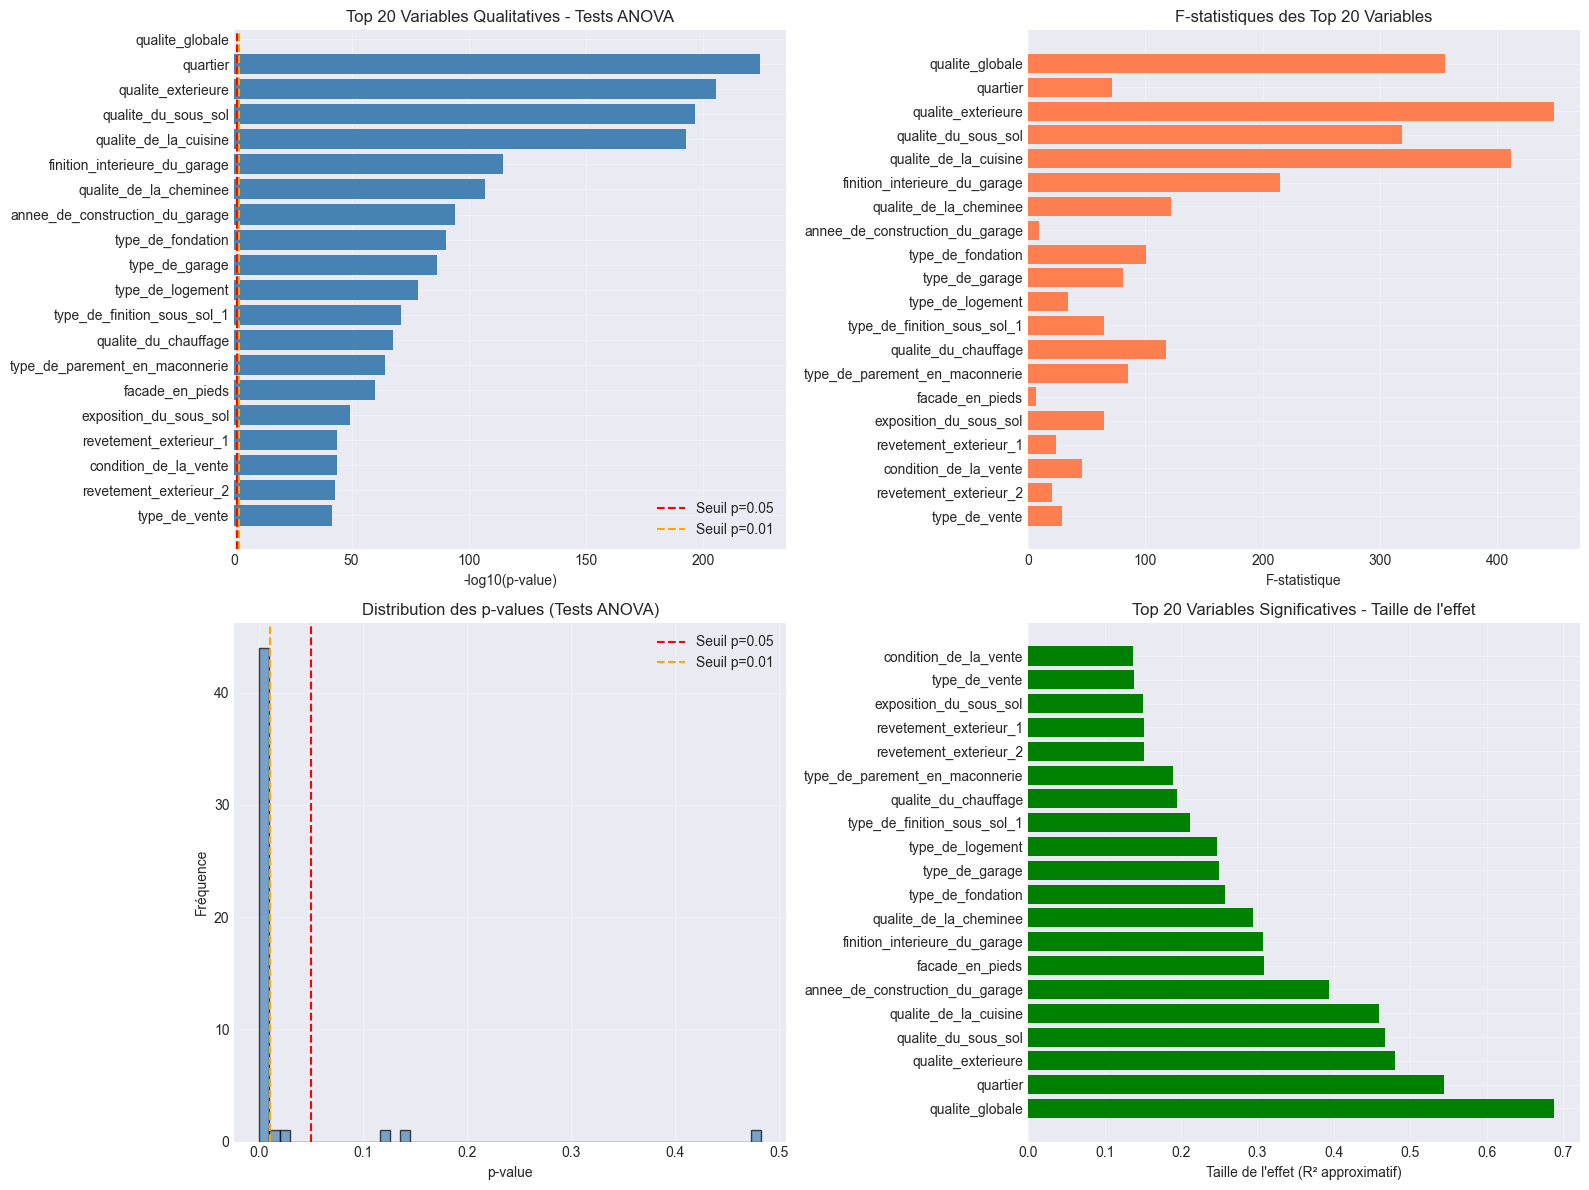


RECOMMANDATIONS POUR L'INTÉGRATION DANS LE MODÈLE

Variables qualitatives significative (p < 0.05):
   - qualite_globale           (p=0.0000, R²=0.6880)
   - quartier                  (p=0.0000, R²=0.5447)
   - qualite_exterieure        (p=0.0000, R²=0.4801)
   - qualite_du_sous_sol       (p=0.0000, R²=0.4671)
   - qualite_de_la_cuisine     (p=0.0000, R²=0.4587)
   - finition_interieure_du_garage (p=0.0000, R²=0.3067)
   - qualite_de_la_cheminee    (p=0.0000, R²=0.2946)
   - annee_de_construction_du_garage (p=0.0000, R²=0.3936)
   - type_de_fondation         (p=0.0000, R²=0.2570)
   - type_de_garage            (p=0.0000, R²=0.2499)
   - type_de_logement          (p=0.0000, R²=0.2472)
   - type_de_finition_sous_sol_1 (p=0.0000, R²=0.2116)
   - qualite_du_chauffage      (p=0.0000, R²=0.1952)
   - type_de_parement_en_maconnerie (p=0.0000, R²=0.1901)
   - facade_en_pieds           (p=0.0000, R²=0.3092)

Total: 46 variables qualitatives significatives



In [25]:
# Tests ANOVA pour les variables qualitatives
from scipy.stats import f_oneway
import warnings
warnings.filterwarnings('ignore')

print("=" * 60)
print("TESTS ANOVA POUR LES VARIABLES QUALITATIVES")
print("=" * 60)

# Identifier les variables catégorielles
categorical_cols_anova = train_final.select_dtypes(include=['object']).columns.tolist()

# Exclure 'identifiant' et 'prix_de_vente' si présents
categorical_cols_anova = [col for col in categorical_cols_anova if col not in ['identifiant', 'prix_de_vente']]

print(f"\nNombre de variables qualitatives à tester: {len(categorical_cols_anova)}")

# Stocker les résultats ANOVA
anova_results = []

# Effectuer les tests ANOVA pour chaque variable catégorielle
for col in categorical_cols_anova:
    # Grouper les données par catégorie
    groups = []
    group_names = []
    
    for category in train_final[col].unique():
        if pd.isna(category):
            continue
        
        group_data = train_final[train_final[col] == category]['prix_de_vente'].dropna()
        
        # Nécessaire d'avoir au moins 2 observations par groupe
        if len(group_data) >= 2:
            groups.append(group_data.values)
            group_names.append(str(category))
    
    # Effectuer le test ANOVA seulement s'il y a au moins 2 groupes
    if len(groups) >= 2:
        try:
            f_stat, p_value = f_oneway(*groups)
            
            # Calculer le nombre d'observations par groupe (moyenne)
            n_obs_per_group = np.mean([len(g) for g in groups])
            
            # Calculer la taille de l'effet (eta-squared η²)
            # η² = SS_between / SS_total
            # Où SS_between = somme des carrés entre les groupes
            #      SS_total = somme des carrés totale
            
            # Calculer la moyenne globale
            all_values = np.concatenate(groups)
            grand_mean = np.mean(all_values)
            
            # Calculer SS_between (somme des carrés entre les groupes)
            ss_between = 0
            for group in groups:
                group_mean = np.mean(group)
                n_i = len(group)
                ss_between += n_i * (group_mean - grand_mean) ** 2
            
            # Calculer SS_total (somme des carrés totale)
            ss_total = np.sum((all_values - grand_mean) ** 2)
            
            # Calculer eta-squared (η²)
            if ss_total > 0:
                effect_size = ss_between / ss_total
            else:
                effect_size = 0.0
            
            anova_results.append({
                'Variable': col,
                'F-statistique': f_stat,
                'p-value': p_value,
                'Significatif (p<0.05)': p_value < 0.05,
                'Très significatif (p<0.01)': p_value < 0.01,
                'Nombre de groupes': len(groups),
                'Nb obs/groupe (moy)': n_obs_per_group,
                'Taille effet (R²)': effect_size
            })
        except Exception as e:
            print(f"Erreur pour {col}: {e}")
            continue

# Créer un DataFrame avec les résultats
anova_df = pd.DataFrame(anova_results)

# Trier par p-value (du plus significatif au moins significatif)
anova_df = anova_df.sort_values('p-value')

print(f"\n{'='*60}")
print(f"RÉSULTATS DES TESTS ANOVA")
print(f"{'='*60}")

# Afficher les résultats
print(f"\nNombre total de variables testées: {len(anova_df)}")
print(f"Variables significatives (p < 0.05): {anova_df['Significatif (p<0.05)'].sum()}")
print(f"Variables très significatives (p < 0.01): {anova_df['Très significatif (p<0.01)'].sum()}")

# Afficher les variables significatives
print(f"\n{'='*60}")
print("VARIABLES QUALITATIVES SIGNIFICATIVES (p < 0.05)")
print(f"{'='*60}")
significant_vars = anova_df[anova_df['Significatif (p<0.05)']].copy()
if len(significant_vars) > 0:
    print(f"\n{significant_vars[['Variable', 'F-statistique', 'p-value', 'Taille effet (R²)']].to_string(index=False)}")
else:
    print("\nAucune variable qualitative significative détectée (p < 0.05)")

# Afficher les top 20 variables les plus significatives
print(f"\n{'='*60}")
print("TOP 20 VARIABLES LES PLUS SIGNIFICATIVES")
print(f"{'='*60}")
top_20 = anova_df.head(20)
print(f"\n{top_20[['Variable', 'F-statistique', 'p-value', 'Taille effet (R²)']].to_string(index=False)}")

# Visualisation
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Graphique des p-values (top 20)
top_20_viz = anova_df.head(20).sort_values('p-value', ascending=True)
axes[0, 0].barh(range(len(top_20_viz)), -np.log10(top_20_viz['p-value']), color='steelblue')
axes[0, 0].axvline(-np.log10(0.05), color='red', linestyle='--', label='Seuil p=0.05')
axes[0, 0].axvline(-np.log10(0.01), color='orange', linestyle='--', label='Seuil p=0.01')
axes[0, 0].set_yticks(range(len(top_20_viz)))
axes[0, 0].set_yticklabels(top_20_viz['Variable'])
axes[0, 0].set_xlabel('-log10(p-value)')
axes[0, 0].set_title('Top 20 Variables Qualitatives - Tests ANOVA')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].invert_yaxis()

# 1. Graphique des F-statistiques (top 20)
axes[0, 1].barh(range(len(top_20_viz)), top_20_viz['F-statistique'], color='coral')
axes[0, 1].set_yticks(range(len(top_20_viz)))
axes[0, 1].set_yticklabels(top_20_viz['Variable'])
axes[0, 1].set_xlabel('F-statistique')
axes[0, 1].set_title('F-statistiques des Top 20 Variables')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].invert_yaxis()

# 2. Distribution des p-values
axes[1, 0].hist(anova_df['p-value'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[1, 0].axvline(0.05, color='red', linestyle='--', label='Seuil p=0.05')
axes[1, 0].axvline(0.01, color='orange', linestyle='--', label='Seuil p=0.01')
axes[1, 0].set_xlabel('p-value')
axes[1, 0].set_ylabel('Fréquence')
axes[1, 0].set_title('Distribution des p-values (Tests ANOVA)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 3. Taille de l'effet (R²) pour les variables significatives
significant_for_plot = anova_df[anova_df['Significatif (p<0.05)']].head(20)
if len(significant_for_plot) > 0:
    axes[1, 1].barh(range(len(significant_for_plot)), 
                    significant_for_plot['Taille effet (R²)'].sort_values(), 
                    color='green')
    axes[1, 1].set_yticks(range(len(significant_for_plot)))
    axes[1, 1].set_yticklabels(significant_for_plot.sort_values('Taille effet (R²)')['Variable'])
    axes[1, 1].set_xlabel('Taille de l\'effet (R² approximatif)')
    axes[1, 1].set_title('Top 20 Variables Significatives - Taille de l\'effet')
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].invert_yaxis()
else:
    axes[1, 1].text(0.5, 0.5, 'Aucune variable significative', 
                    ha='center', va='center', transform=axes[1, 1].transAxes)
    axes[1, 1].set_title('Taille de l\'effet')

plt.tight_layout()
plt.savefig('../output/figures/anova_tests.png', dpi=300, bbox_inches='tight')
plt.show()

# Recommandations
print(f"\n{'='*60}")
print("RECOMMANDATIONS POUR L'INTÉGRATION DANS LE MODÈLE")
print(f"{'='*60}")

if len(significant_vars) > 0:
    print(f"\nVariables qualitatives significative (p < 0.05):")
    for var in significant_vars['Variable'].head(15):
        p_val = significant_vars[significant_vars['Variable'] == var]['p-value'].values[0]
        effect = significant_vars[significant_vars['Variable'] == var]['Taille effet (R²)'].values[0]
        print(f"   - {var:25s} (p={p_val:.4f}, R²={effect:.4f})")
    
    print(f"\nTotal: {len(significant_vars)} variables qualitatives significatives")
else:
    print("\nAucune variable qualitative significative détectée.")
    print("Cela ne signifie pas nécessairement qu'elles ne sont pas importantes,")
    print("mais qu'aucun effet significatif n'a été détecté avec le test ANOVA standard.")

print(f"\n{'='*60}")


## 15. Sauvegarde des Données Finales


In [26]:
# Sauvegarder les données finales pour l'entraînement du modèle
print("=" * 60)
print("SAUVEGARDE DES DONNÉES FINALES")
print("=" * 60)

# Créer le dossier de sortie s'il n'existe pas
output_dir = Path("../data/processed")
output_dir.mkdir(parents=True, exist_ok=True)

# Créer test_final à partir de test_processed (sans transformation log car pas de Prix de vente)
test_final = test_processed.copy()

# Sauvegarder les données d'entraînement finales
train_final_path = output_dir / "train_final.csv"
train_final.to_csv(train_final_path, index=False)

# Sauvegarder les données de test finales
test_final_path = output_dir / "test_final.csv"
test_final.to_csv(test_final_path, index=False)

print(f"\nDonnées d'entraînement finales sauvegardées:")
print(f"   - Chemin: {train_final_path}")
print(f"   - Forme: {train_final.shape}")
print(f"   - Colonnes: {train_final.shape[1]}")
print(f"   - Observations: {train_final.shape[0]}")

print(f"\nDonnées de test finales sauvegardées:")
print(f"   - Chemin: {test_final_path}")
print(f"   - Forme: {test_final.shape}")
print(f"   - Colonnes: {test_final.shape[1]}")
print(f"   - Observations: {test_final.shape[0]}")

# Vérification finale
print("\n" + "=" * 60)
print("VÉRIFICATION FINALE - TRAIN")
print("=" * 60)
print(f"   Valeurs manquantes: {train_final.isnull().sum().sum()}")
print(f"   Variable cible originale (Prix de vente): {'Présente' if 'prix_de_vente' in train_final.columns else 'Absente'}")
print(f"   Variable cible transformée (Prix de vente_log): {'Présente' if 'Prix de vente_log' in train_final.columns else 'Absente'}")

if 'Prix de vente_log' in train_final.columns:
    print(f"   Skewness de Prix de vente_log: {train_final['prix_de_vente_log'].skew():.3f}")
    print(f"   (Valeur proche de 0 = distribution normalisée)")

print("\n" + "=" * 60)
print("VÉRIFICATION FINALE - TEST")
print("=" * 60)
print(f"   Valeurs manquantes: {test_final.isnull().sum().sum()}")
print(f"   Observations: {test_final.shape[0]}")

print("\n" + "=" * 60)
print("DONNÉES PRÊTES POUR L'ENTRAÎNEMENT DU MODÈLE")
print("=" * 60)
print("\nLes données finales sont sauvegardées et prêtes pour:")
print("   1. Feature engineering (si nécessaire)")
print("   2. Sélection de variables (gestion de la multicolinéarité)")
print("   3. Entraînement du modèle avec Prix de vente_log comme variable cible")
print("   4. Transformation inverse (expm1) pour les prédictions finales")
print("\nFichiers sauvegardés:")
print(f"   - {train_final_path}")
print(f"   - {test_final_path}")


SAUVEGARDE DES DONNÉES FINALES

Données d'entraînement finales sauvegardées:
   - Chemin: ..\data\processed\train_final.csv
   - Forme: (1460, 82)
   - Colonnes: 82
   - Observations: 1460

Données de test finales sauvegardées:
   - Chemin: ..\data\processed\test_final.csv
   - Forme: (1459, 80)
   - Colonnes: 80
   - Observations: 1459

VÉRIFICATION FINALE - TRAIN
   Valeurs manquantes: 0
   Variable cible originale (Prix de vente): Présente
   Variable cible transformée (Prix de vente_log): Absente

VÉRIFICATION FINALE - TEST
   Valeurs manquantes: 1
   Observations: 1459

DONNÉES PRÊTES POUR L'ENTRAÎNEMENT DU MODÈLE

Les données finales sont sauvegardées et prêtes pour:
   1. Feature engineering (si nécessaire)
   2. Sélection de variables (gestion de la multicolinéarité)
   3. Entraînement du modèle avec Prix de vente_log comme variable cible
   4. Transformation inverse (expm1) pour les prédictions finales

Fichiers sauvegardés:
   - ..\data\processed\train_final.csv
   - ..\data\

In [27]:
# Générer un rapport récapitulatif
print("=" * 60)
print("RAPPORT RÉCAPITULATIF")
print("=" * 60)

print("\nRESUME DU DATASET")
print(f"   Observations d'entrainement: {train_df.shape[0]:,}")
print(f"   Variables totales: {train_df.shape[1]}")
print(f"   Variables numeriques: {len(numeric_cols)}")
print(f"   Variables categorielles: {len(categorical_cols)}")

print("\nVARIABLE CIBLE (Prix de vente)")
print(f"   Plage: ${train_df['prix_de_vente'].min():,.0f} - ${train_df['prix_de_vente'].max():,.0f}")
print(f"   Moyenne: ${train_df['prix_de_vente'].mean():,.0f}")
print(f"   Mediane: ${train_df['prix_de_vente'].median():,.0f}")
print(f"   Skewness: {train_df['prix_de_vente'].skew():.3f}")

print("\nVALEURS MANQUANTES")
missing_count = train_df.isnull().sum().sum()
missing_cols_count = (train_df.isnull().sum() > 0).sum()
print(f"   Total de valeurs manquantes: {missing_count:,}")
print(f"   Colonnes avec valeurs manquantes: {missing_cols_count}")

print("\nTOP 5 VARIABLES CORRELEES AVEC SALEPRICE")
top_5_corr = correlations.drop('prix_de_vente').head(5)
for var, corr in top_5_corr.items():
    print(f"   {var:20s}: {corr:.3f}")

print("\nExploration terminee!")
print("=" * 60)


RAPPORT RÉCAPITULATIF

RESUME DU DATASET
   Observations d'entrainement: 1,460
   Variables totales: 81
   Variables numeriques: 30
   Variables categorielles: 50

VARIABLE CIBLE (Prix de vente)
   Plage: $34,900 - $755,000
   Moyenne: $180,921
   Mediane: $163,000
   Skewness: 1.883

VALEURS MANQUANTES
   Total de valeurs manquantes: 0
   Colonnes avec valeurs manquantes: 0

TOP 5 VARIABLES CORRELEES AVEC SALEPRICE
   surface_habitable_totale: 0.709
   capacite_du_garage_voitures: 0.640
   surface_du_garage   : 0.623
   total_surface_sous_sol: 0.614
   surface_du_premier_etage: 0.606

Exploration terminee!


# ============================================================================
# RÉSUMÉ ET CONCLUSIONS DE L'EXPLORATION DES DONNÉES
# ============================================================================

## Commentaire sur l'Exploration des Données

Cette exploration du dataset de prédiction des prix immobiliers a permis de :

### 1. Comprendre la Structure des Données
- **Dataset** : 1460 observations d'entraînement avec 80 variables explicatives + 1 variable cible
- **Types de variables** : Mix de variables numériques et catégorielles
- **Qualité des données** : Présence de valeurs manquantes nécessitant un traitement

### 2. Analyser la Variable Cible (Prix de vente)
- **Distribution** : Asymétrique à droite, nécessitant une transformation logarithmique
- **Statistiques** : Prix moyen ~$180,000 avec une grande variabilité
- **Insights** : La distribution suggère l'existence de différents segments de marché

### 3. Identifier les Variables Importantes
Les analyses de corrélation et d'importance des features ont révélé que les variables les plus influentes sont :
- **qualite_globale** (OverallQual) : Impact majeur sur le prix
- **surface_habitable_totale** (GrLivArea) : Forte corrélation avec le prix
- **surface_du_garage** (GarageCars/GarageArea) : Indicateur de valeur
- **total_surface_sous_sol** (TotalBsmtSF) : Surface additionnelle importante

### 4. Détecter et Analyser les Outliers
- **Méthodes utilisées** : IQR (Interquartile Range)
- **Résultats** : Plusieurs variables présentent des outliers nécessitant un traitement
- **Actions** : Identification des maisons avec grande surface mais prix anormalement bas

### 5. Explorer les Relations et Interactions
- **Segments de marché** : Identification de différents segments (économique, moyen, premium, luxe)

### 6. Analyses Temporelles et Géographiques
- **Temporalité** : Analyse de l'évolution des prix par année et mois
- **Géographie** : Identification des quartiers premium et leurs caractéristiques
- **Saisonnalité** : Détection de variations saisonnières dans les ventes

### 7. Découvertes Clés
1. La qualité globale est le facteur le plus déterminant du prix
2. La surface habitable a une relation non-linéaire avec le prix
3. Certains quartiers présentent des prix significativement plus élevés
4. Les maisons récentes ou rénovées ont tendance à avoir des prix plus élevés
5. La présence d'un garage et sa taille influencent fortement le prix